# I. Introduction

## A. Project Background
Bike-sharing systems offer a convenient and eco-friendly means of transport by allowing clients to rent out bikes for short durations, typically on an automated docking system. Customers can rent out a bicycle from one stand and return it at any other stand in the scheme, making bike-sharing ideal for daily commutes, spontaneous outings, and leisure cycles within cities.

Whereas the ease of use of these systems is attractive, supply and demand control remains a major operational issue. Rental patterns are influenced by the time of day, weather, public holidays, and seasonality. Imbalances also occur with some stations experiencing a shortage of bikes and others having too many, leading to frustration among customers and inefficiencies.


## B. Project Objective
The goal of this project is to examine historical bike rental data and determine the primary factors that affect rental demand. By identifying trends and building predictive models, the project aims to contribute to better resource allocation, demand forecasting, and overall operational planning for bike-sharing schemes.


## C. Research Questions

   1.)   What are the temporal patterns (hour of day, day of week, season) that induce variability in rental volume?

   2.)   How do environmental conditions (temperature, humidity, windspeed) affect demand for rentals?

   3.)   Do registered and casual users have significantly different behavior?

   4.)   Can one predict rental count based on environmental and temporal features?
   
   5.)  Can one cluster similar usage patterns to identify peak demand scenarios?


## D. Business Objective

The objective is to develop a predictive model that predicted bike rental demand using various independent variables such as time of day, weather, seasonality, and type of user. The model will enable the management to better know how demand changes based on these variables.

With these insights, the business can:


*   Maximize operational strategies such as bike redistributing, staffing, and maintenance scheduling.
*   Enhance client satisfaction by making available bicycles during high demand periods.
*   Enabling data-based decision-making on market entry by simulating demand under changing environmental and time conditions.


Lastly, the model serves as a strategic tool for supply-demand matching, minimizing missed opportunities, and maximizing overall efficiency of service.

# II. Exploratory Data Analysis (EDA)

## A.  Dataset Structure Overview

The hour_dataset consists of a single worksheet with 17,379 rows, where each row represents an hourly record of bike rentals from 2011 to 2012. It includes 17 columns, capturing various temporal, weather-related, and usage attributes.

On the otherhand, the day_dataset consists of a single worksheet with 731 rows, where each row represents a single day of bike rental data collected from January 2011 to December 2012. It includes 16 columns, capturing calendar, weather, and usage attributes relevant to daily demand patterns.

**Features Name and Definitions**

- `instant`: record index
- `dteday` : date
- `season` : season (1:winter, 2:spring, 3:summer, 4:fall)
- `yr` : year (0: 2011, 1:2012)
- `mnth` : month ( 1 to 12)
- `hr` : hour (0 to 23)
- `holiday` : weather day is holiday or not
- `weekday` : day of the week
- `workingday` : if day is neither weekend nor holiday is 1, otherwise is 0.
- `weathersit` :

    1: Clear, Few clouds, Partly cloudy, Partly cloudy

    2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

    3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

    4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- `temp` : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- `atemp`: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- `hum`: Normalized humidity. The values are divided to 100 (max)
- `windspeed`: Normalized wind speed. The values are divided to 67 (max)
- `casual`: count of casual users
- `registered`: count of registered users
- `cnt`: count of total rental bikes including both casual and registered

## B. Loading and Inspecting the Data

In [1]:
#Import necessary libraries
#for DA and array processing
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Load the dataset

# Load the hour.csv file
hour_df = pd.read_csv('hour.csv')
# hour_df = pd.read_csv('hour.csv')


# Load the day.csv file
day_df = pd.read_csv('day.csv')
# day_df = pd.read_csv('day.csv')

#Read the data
#df.head().style.background_gradient(cmap='Greys')

# Display basic info about both datasets
print("Hourly Data Shape:", hour_df.shape)
print("Daily Data Shape:", day_df.shape)

Hourly Data Shape: (17379, 17)
Daily Data Shape: (731, 16)


= The two datasets provided in the Bike Sharing Dataset, `hour.csv` and `day.csv`, were loaded successfully.

- **hour.csv** contains 17,379 rows and 17 columns, representing hourly bike rental data for the years 2011 and 2012.
- **day.csv** contains 731 rows and 16 columns, summarizing daily rental counts over the same period.

This step was necessary to understand the structure and size of the datasets and to evaluate their suitability for exploratory analysis and modeling.

In [2]:
# Show first few rows of each dataframe
print("\nFirst 5 rows of hourly data:")
hour_df.head()


First 5 rows of hourly data:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


= Inspecting the first five rows of the hourly dataset provides an initial overview of the data structure and the types of variables included. This preview confirms the presence of temporal features (e.g., season, yr, mnth, hr, weekday) and environmental factors (e.g., temp, atemp, hum, windspeed), as well as target variables such as casual, registered, and cnt.

Observing these rows helps verify that the dataset was loaded correctly and provides an opportunity to identify potential formatting issues or anomalies at an early stage.

In [3]:
hour_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,17379.0,NaN,NaN,NaN,8690.0,5017.0295,1.0,4345.5,8690.0,13034.5,17379.0
dteday,17379,731,2012-12-31,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0


= The summary statistics highlight the distribution and variability of all numerical features. For instance, cnt ranges from 1 to 977 with a mean of 189, showing high variability in hourly demand. Features such as temp, hum, and windspeed are normalized and within expected ranges. This step helps detect outliers and informs data preparation

In [4]:
print("\nFirst 5 rows of daily data:")
day_df.head()


First 5 rows of daily data:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


= Displaying the first five rows of the daily dataset provides an overview of feature types and their initial values. This step confirms that the dataset includes temporal, environmental, and target variables (cnt) in the expected format. It also helps verify successful loading and detect any obvious formatting issues.

In [5]:
day_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,731.0,NaN,NaN,NaN,366.0,211.165812,1.0,183.5,366.0,548.5,731.0
dteday,731,731,2012-12-31,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,731.0,NaN,NaN,NaN,2.49658,1.110807,1.0,2.0,3.0,3.0,4.0
yr,731.0,NaN,NaN,NaN,0.500684,0.500342,0.0,0.0,1.0,1.0,1.0
mnth,731.0,NaN,NaN,NaN,6.519836,3.451913,1.0,4.0,7.0,10.0,12.0
holiday,731.0,NaN,NaN,NaN,0.028728,0.167155,0.0,0.0,0.0,0.0,1.0
weekday,731.0,NaN,NaN,NaN,2.997264,2.004787,0.0,1.0,3.0,5.0,6.0
workingday,731.0,NaN,NaN,NaN,0.683995,0.465233,0.0,0.0,1.0,1.0,1.0
weathersit,731.0,NaN,NaN,NaN,1.395349,0.544894,1.0,1.0,1.0,2.0,3.0
temp,731.0,NaN,NaN,NaN,0.495385,0.183051,0.05913,0.337083,0.498333,0.655417,0.861667


= The summary statistics provide insights into the distribution and scale of all numerical features in the daily dataset. The target variable cnt ranges from 22 to 8,714 with a mean of 4,504, indicating substantial variability in daily rentals. Features such as temp, hum, and windspeed display normalized ranges suitable for modeling. This step aids in detecting outliers and understanding data characteristics before further processing.

In [6]:
# Display the count of unique values for each column
print("Unique values per column: Hour")
hour_df.nunique()

Unique values per column: Hour


instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64

= The count of unique values per column helps assess the variability and categorical nature of features in the hourly dataset. Categorical variables such as season, yr, holiday, and weekday have expected unique counts, confirming appropriate encoding. Continuous variables like temp, atemp, and cnt show higher unique counts, indicating sufficient granularity for analysis. This step supports understanding feature types and guides preprocessing decisions such as encoding or scaling.

In [7]:
# Display the count of unique values for each column
print("\nUnique values per column: Day")
day_df.nunique()


Unique values per column: Day


instant       731
dteday        731
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          499
atemp         690
hum           595
windspeed     650
casual        606
registered    679
cnt           696
dtype: int64

= The count of unique values highlights the variability of features in the daily dataset. Categorical variables such as season, yr, holiday, and weekday display expected distinct values, confirming proper encoding. Continuous variables like temp, atemp, hum, and cnt exhibit high uniqueness, ensuring detailed representation of daily variations. This assessment supports feature type identification and informs preprocessing steps such as scaling or feature selection.

**Decision and Justification for Using the Hourly Dataset**

Our team has chosen to use the hourly dataset as it offers a more granular and actionable view of bike rental patterns compared to the daily dataset. By capturing time-of-day trends like rush hour spikes and midday drops in usage it enables better understanding of user behavior and supports real-time operations planning and exact demand prediction.

Hourly data not only tells us how much demand exists on a given day, but more valuably, when it exists. This level of detail is necessary to fine-tune bicycle redistribution during peak times, adjust staff rosters, and be able to respond to sudden changes in the weather. These sorts of conclusions cannot be made using the aggregated daily data set, making hourly data of higher value for tactical business decision-making.

## C. Visualizing Key Trends and Patterns

In [8]:
#For Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, probplot

### 0. Compare to hour_df and day_df

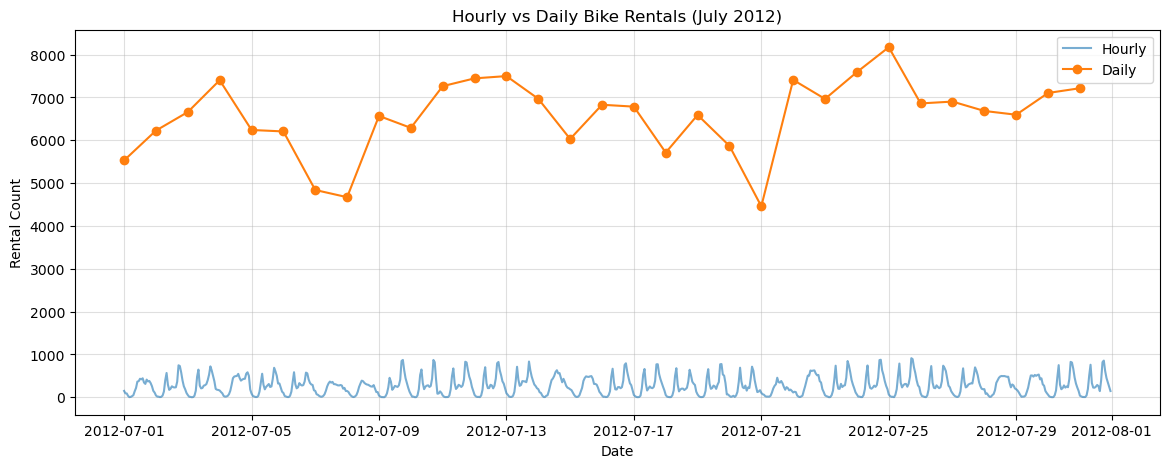

In [9]:

hour_df['datetime'] = pd.to_datetime(hour_df['dteday']) + pd.to_timedelta(hour_df['hr'], unit='h')
day_df['datetime'] = pd.to_datetime(day_df['dteday'])

# set the time
hour_subset = hour_df[(hour_df['datetime'] >= '2012-07-01') & (hour_df['datetime'] < '2012-08-01')]
day_subset = day_df[(day_df['datetime'] >= '2012-07-01') & (day_df['datetime'] < '2012-08-01')]


plt.figure(figsize=(14,5))
plt.plot(hour_subset['datetime'], hour_subset['cnt'], label='Hourly', alpha=0.6)
plt.plot(day_subset['datetime'], day_subset['cnt'], label='Daily', marker='o')
plt.title("Hourly vs Daily Bike Rentals (July 2012)")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.grid(True,alpha=0.4)
plt.legend()
plt.show()


= The line plot compares hourly and daily bike rentals during July 2012.

**Explanation**

- The hourly data (hour_df) shows a detailed, fluctuating pattern with clear peaks and valleys throughout each day, reflecting real-time demand variations such as morning and evening commuting hours or weather-related drops.

- The daily data (day_df) provides a smoother trend that captures the overall rental count per day, but it masks the intra-day patterns and user behavior within each day.

**Why hour_df**

- More granularity: The hourly line reveals intra-day demand changes, such as rush hour spikes or mid-day drops, which are completely hidden in daily totals.

- Better for operational planning: If a city wants to allocate bikes or manage staff shifts, knowing hourly demand is essential.

- Improves forecasting accuracy: Models built on hour_df can learn time-of-day effects, which are crucial for precise demand prediction.


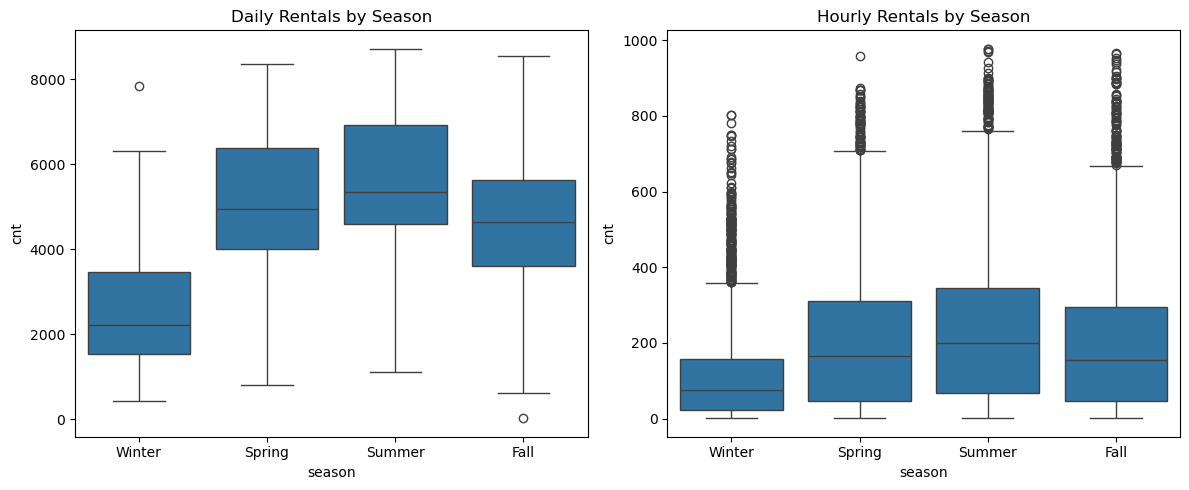

In [10]:
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df, x='season', y='cnt')
plt.xticks(ticks=[0,1,2,3], labels=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title("Daily Rentals by Season")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df, x='season', y='cnt')
plt.xticks(ticks=[0,1,2,3], labels=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title("Hourly Rentals by Season")

plt.tight_layout()
plt.show()

#season (1:winter, 2:spring, 3:summer, 4:fall)

= The boxplots compare bike rental counts (cnt) across seasons, using both daily-level data (day_df) and hourly-level data (hour_df).

**Explanation**

Y-Axis Difference

- day_df (left): Rental counts range from 0 to 9000, since it's the total count per day.

- hour_df (right): Rental counts range from 0 to 1000, because it's the count per hour.

X-Axis: Season Labels

**Why hour_df**
- Finer granularity:
  - hour_df captures hourly rental activity, revealing within-day patterns such as commuting peaks in the morning and evening
  - day_df aggregates data to daily total, masking fluctuations that occur throughout the day.

- Box Size and IQR Differences:

  - Daily Rentals (day_df):
Each season shows a relatively wide interquartile range (IQR), meaning that the total number of rentals per day varies significantly within a season. For example, in the Summer season, both the median and the range between the 25th and 75th percentiles are high, indicating substantial daily variability.

  - Hourly Rentals (hour_df):
The boxes are comparatively narrower, suggesting that hourly rental counts tend to stay within a more consistent range. However, there are a large number of outliers, indicating a wide variety of rental volumes at specific hours.

  - For example, In the Spring season, the IQR (box size) for day_df spans roughly 4,000 to 6,000, indicating large day-to-day variability.

  - In hour_df, the same season’s IQR spans about 10 to 300, reflecting more consistent hourly usage.

  - This means while day_df appears to have larger boxes, it's due to the overall larger magnitude of daily totals, not necessarily more behavioral insight.

- Outlier Detection:

  - hour_df shows many outliers, representing unique high-usage hours possibly due to events, weather, or other conditions.

  - day_df shows far fewer outliers, making it harder to detect and explain anomalies in demand.

- Operational Optimization:

  - Cities or bike-sharing companies need to allocate bikes or staff per hour, not per day.

  - Hourly data supports real-time decision-making and resource planning in a way that daily summaries cannot.

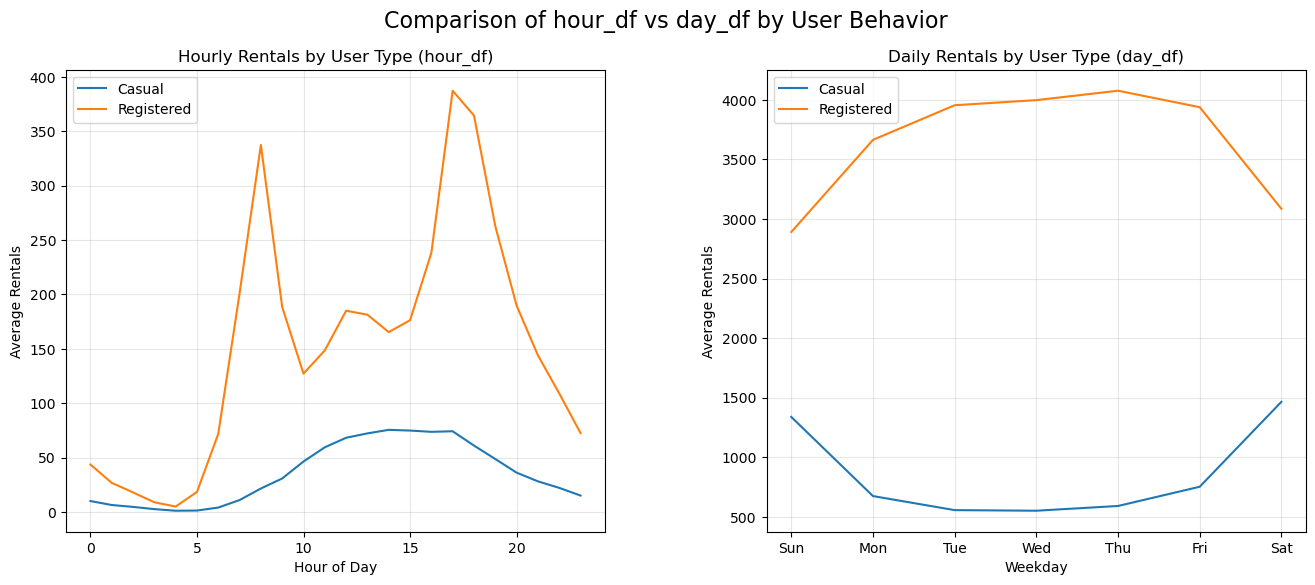

In [11]:
hourly_avg = hour_df.groupby('hr')[['casual', 'registered']].mean().reset_index()


daily_avg = day_df.groupby('weekday')[['casual', 'registered']].mean().reset_index()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.3)

# Hourly rentals by user type
sns.lineplot(ax=axes[0], data=hourly_avg, x='hr', y='casual', label='Casual')
sns.lineplot(ax=axes[0], data=hourly_avg, x='hr', y='registered', label='Registered')
axes[0].set_title('Hourly Rentals by User Type (hour_df)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Rentals')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Daily rentals by user type
sns.lineplot(ax=axes[1], data=daily_avg, x='weekday', y='casual', label='Casual')
sns.lineplot(ax=axes[1], data=daily_avg, x='weekday', y='registered', label='Registered')
axes[1].set_title('Daily Rentals by User Type (day_df)')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Average Rentals')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('Comparison of hour_df vs day_df by User Behavior', fontsize=16)
plt.show()


= The dual line plots compare user rental behavior between hourly and daily data.

**Explanation**

Left Plot (hour_df):

- Clear peaks: Registered users peak at 8 AM and 5–6 PM (commute).

- Casual users rise midday, peaking around 1–2 PM (leisure).

- High temporal granularity reveals hour-specific behavior.

Right Plot (day_df):

- Flatter trends: Weekday differences exist, but no intra-day pattern.

- Peaks are smoothed out, making it hard to tell when during the day rentals happen.

**Why hour_df**

- Reveals intra-day behavior: hour_df captures commuting vs. leisure peaks, which are hidden in day_df.

- Crucial for forecasting: Time-of-day effect is important in predicting demand and managing bike supply dynamically.

- User differentiation: hour_df makes it easy to see how casual and registered users differ across hours, helping in segmentation.

- hour_df helps cities or companies optimize operations by adjusting bike or staff allocation according to hourly demand.

### 1. Line Plots

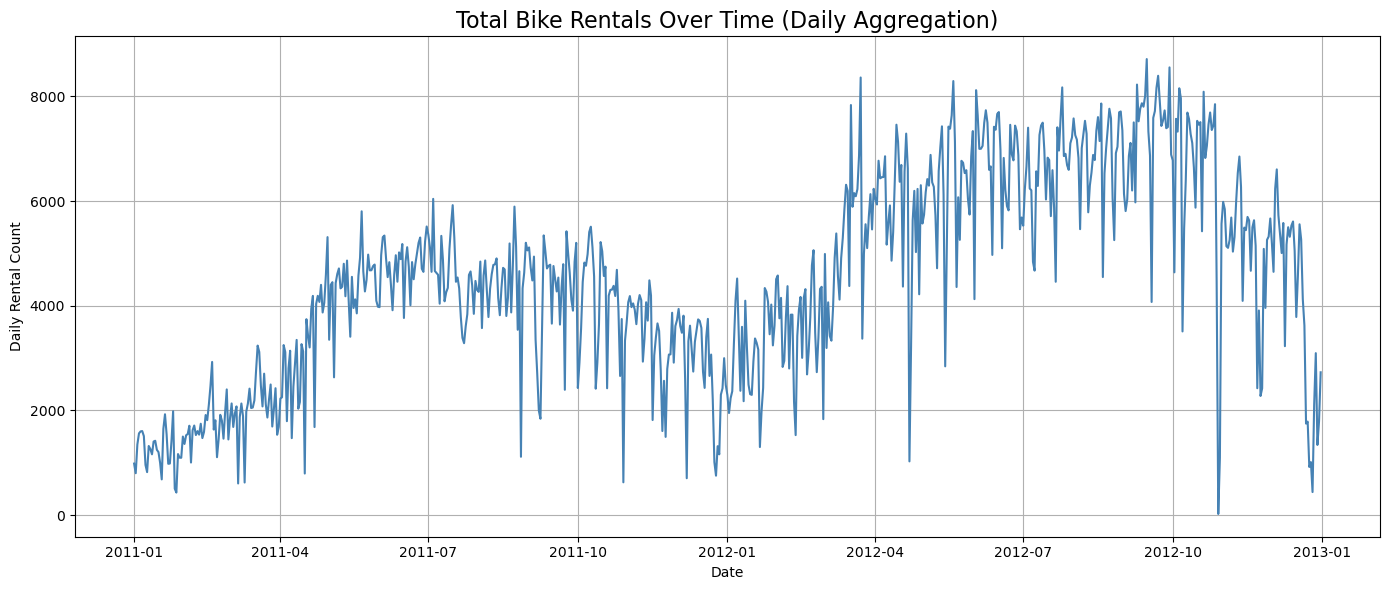

In [12]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df['datetime'] = hour_df['dteday'] + pd.to_timedelta(hour_df['hr'], unit='h')

# Resample to daily total rentals
daily_df = hour_df.resample('D', on='datetime')['cnt'].sum().reset_index()

# Plot the resampled daily trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_df, x='datetime', y='cnt', color='steelblue')
plt.title('Total Bike Rentals Over Time (Daily Aggregation)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Rental Count')
plt.grid(True)
plt.tight_layout()
plt.show()

= The line plot illustrates the total bike rentals aggregated on a daily basis over the two-year period. Clear seasonal patterns are visible, with higher rental counts during warmer months and lower counts in winter. Several sharp drops in rentals may correspond to adverse weather or holidays. This visualization helps identify overall trends, seasonal effects, and potential anomalies in the dataset, informing feature engineering and model selection for time-dependent predictions

- Between early 2011 and late 2012, there was a strong upward trend.
- Seasonal cycles are noticeable, with dips in winter and peaks in summer.
- A notable drop around January 2012, most likely due to severe weather or system outage.
- In 2012, there are more highs and fewer lows than in 2011.

**Why This Matters**
 - Captures long-term trends: The upward trajectory highlights growth in bike rental usage, which can inform business performance analysis and future demand expectations.

- Reveals seasonality: Distinct seasonal patterns (summer peaks, winter dips) emphasize the need to include seasonal or calendar-based features in forecasting models.

- Detects anomalies: Sudden drops (e.g., January 2012) signal potential disruptions such as extreme weather or system issues, which are critical for data cleaning and anomaly handling.

- Supports time-aware modeling: The observed time-dependent patterns justify the use of time series models or time-based train/test splits for more accurate predictions.

- Informs feature engineering: Insights from the plot guide the creation of features like month, season, is_holiday, or lag-based variables to improve model performance.

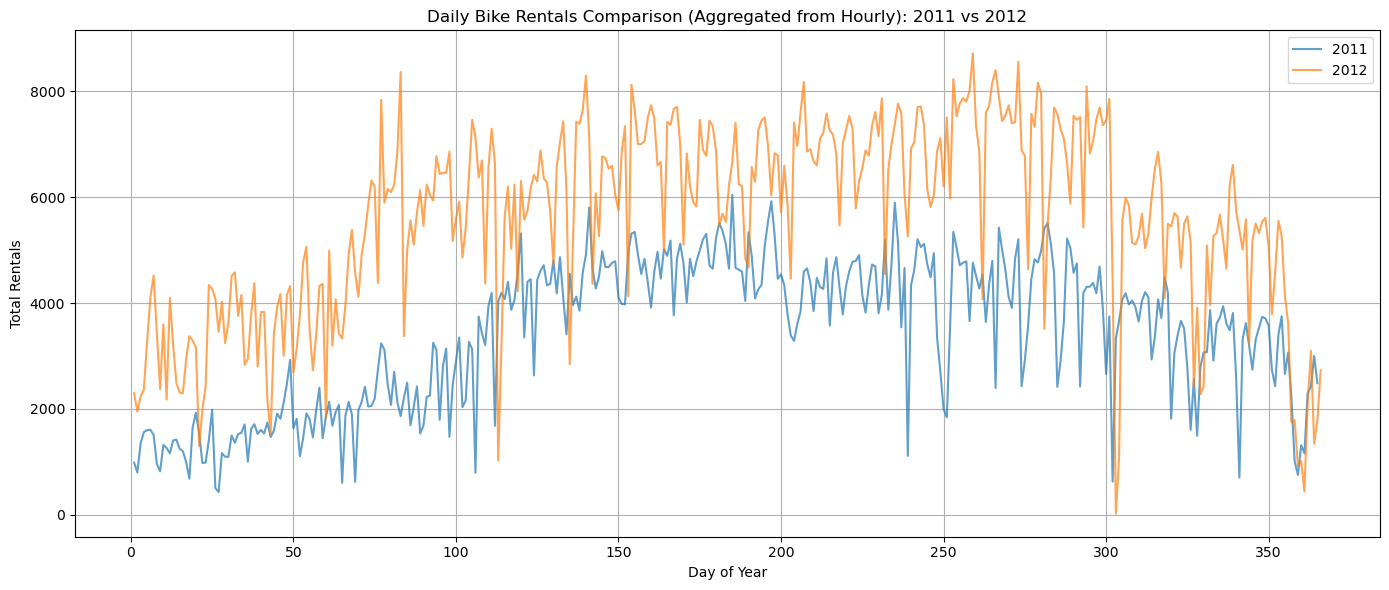

In [13]:
# Extract year and day of year
hour_df['year'] = hour_df['datetime'].dt.year
hour_df['dayofyear'] = hour_df['datetime'].dt.dayofyear

# Group by year and dayofyear to sum daily rentals
daily_hourly = hour_df.groupby(['year', 'dayofyear'])['cnt'].sum().reset_index()

# Split data
df_2011 = daily_hourly[daily_hourly['year'] == 2011]
df_2012 = daily_hourly[daily_hourly['year'] == 2012]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_2011['dayofyear'], df_2011['cnt'], label='2011', alpha=0.7)
plt.plot(df_2012['dayofyear'], df_2012['cnt'], label='2012', alpha=0.7)
plt.title('Daily Bike Rentals Comparison (Aggregated from Hourly): 2011 vs 2012')
plt.xlabel('Day of Year')
plt.ylabel('Total Rentals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

= This line plot compares daily bike rental patterns between 2011 and 2012, aggregated from the hourly dataset. The plot shows higher rental counts in 2012 across most of the year, suggesting overall growth in demand. Seasonal trends are visible in both years, with peaks during warmer months and declines during winter. This visualization supports identifying year-specific trends and variations, which can guide feature engineering for predictive modeling.

- Rentals in 2012 were continuously higher than in 2011, throughout the year.
- Rentals have increased significantly since early spring (around days 70-100).
- Summer peak activity (days 150-250) for both years, with 2012 being notably pronounced.
- Gradual decline in the fall, followed by a dramatic drop around day 300 (most likely due to weather).
- Occasional spikes or declines (sudden dips on days 110 and 300)

**Why This Matter**
- This plot helps visualize year-over-year growth in bike rentals, confirming that demand increased in 2012 compared to 2011.

- It reveals seasonal trends and calendar-driven patterns—such as spring surges and winter declines—which are essential for feature engineering in predictive models.

- By comparing two full years side by side, it becomes easier to detect year-specific anomalies (e.g., sudden drops around day 300), informing decisions around data cleaning and model robustness.

- The visualization supports time-aware modeling strategies by highlighting both cyclical patterns and long-term changes in user behavior.

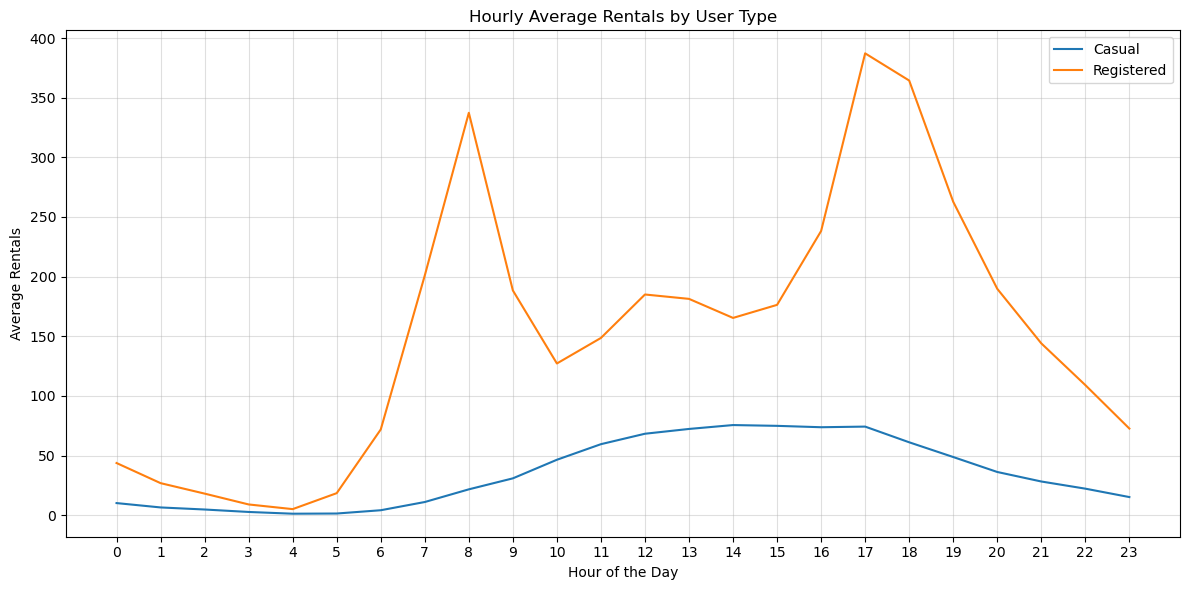

In [14]:
# Hourly Usage Pattern by User Type

hourly_avg = hour_df.groupby('hr')[['casual', 'registered']].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_avg, x='hr', y='casual', label='Casual')
sns.lineplot(data=hourly_avg, x='hr', y='registered', label='Registered')
plt.title('Hourly Average Rentals by User Type')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


= The line plot illustrates the average number of hourly rentals for casual and registered users throughout the day (0 to 23 hours).
This differentiation captures distinct temporal usage behaviors and reinforces the value of hourly granularity in exploratory analysis and demand forecasting.


**Registered users:**

- The Orange line show two sharp peaks—one around 8 AM and another around 5~6 PM, which align with typical commute times.

- Exhibit a repetitive daily pattern, reflecting a routine-based usage likely tied to work or school schedules.

- Rentals are consistently higher during weekdays, supporting the idea that these users rely on bikes for structured, time-bound travel.

**Causal users:**
- Display a single broad peak in the afternoon (1 PM to 5 PM), with usage gradually increasing from late morning.

- Show minimal activity in early morning and late evening hours.

- This behavior reflects a more leisure-driven usage, often aligned with weekends, tourism, or non-commuting purposes.


**Why This Matters**
- This graph transforms raw hourly data into actionable insights by uncovering when and how different user groups behave. It directly informs modeling, operations, and strategic decisions, making it a vital part of exploratory data analysis.



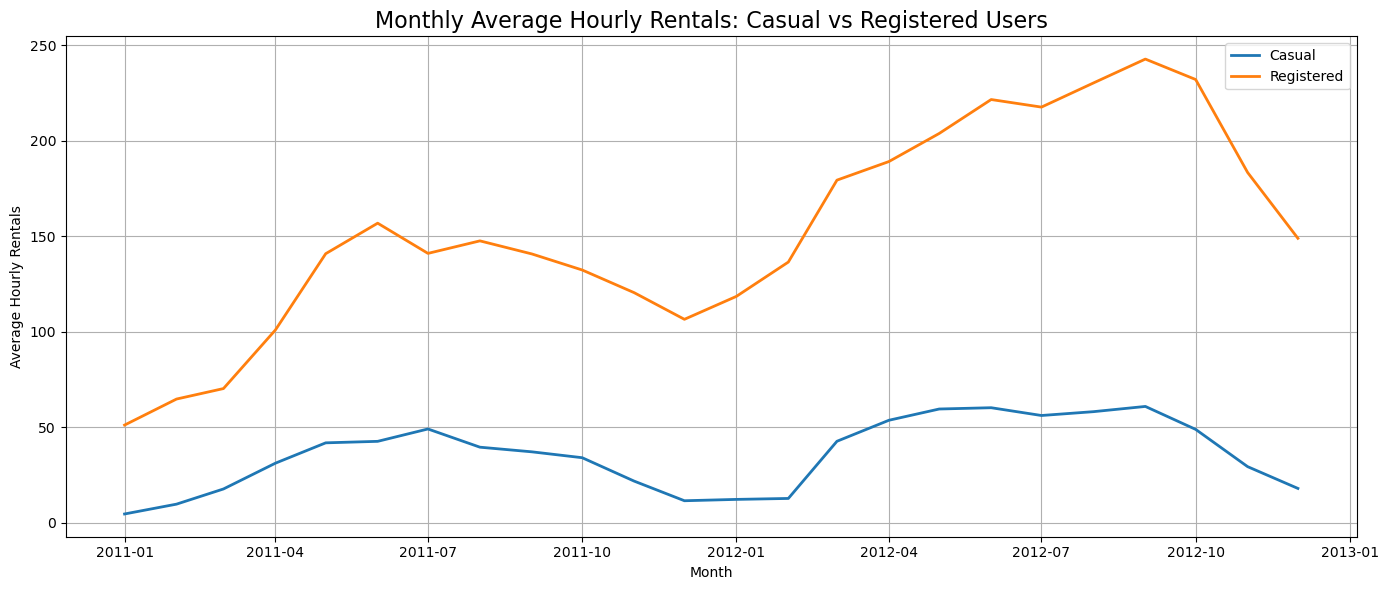

In [15]:
# Group by month and compute average hourly rentals per day per user type
hour_df['month'] = hour_df['datetime'].dt.month

# Group by year and month to preserve time series
monthly_avg = hour_df.groupby(['year', 'month'])[['casual', 'registered']].mean().reset_index()

# Create a datetime column for plotting
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

# Plot average hourly rentals by month
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg, x='date', y='casual', label='Casual', linewidth=2)
sns.lineplot(data=monthly_avg, x='date', y='registered', label='Registered', linewidth=2)

plt.title('Monthly Average Hourly Rentals: Casual vs Registered Users', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Hourly Rentals')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


= The line plot compares average hourly rentals for casual and registered users across months. This differentiation highlights distinct usage patterns between the two groups and reinforces the importance of considering user types in exploratory analysis and modeling decision

**Registered users**:

- Show sustained growth through mid-2012, culminating around September/October 2012.


- There are slight seasonal declines in the winter, although they are less significant than among casual users.

**Casual users**:

- Highly seasonal, peaking between July and August of each year.

- The winter months (December-February) are low in activity.

**Why This Matters**

- This visualization highlights the fundamental behavioral differences between casual and registered users, which is essential for segmented analysis and personalized modeling.

- The clear seasonality in casual usage suggests a strong dependence on weather and leisure trends, while registered users show more consistent, commute-driven behavior.

- These insights support the inclusion of user type as a key feature in forecasting models and help tailor marketing strategies, resource allocation, and operational planning for each group.

- Understanding how demand patterns vary by user type enhances model interpretability and leads to more targeted, effective business decisions.

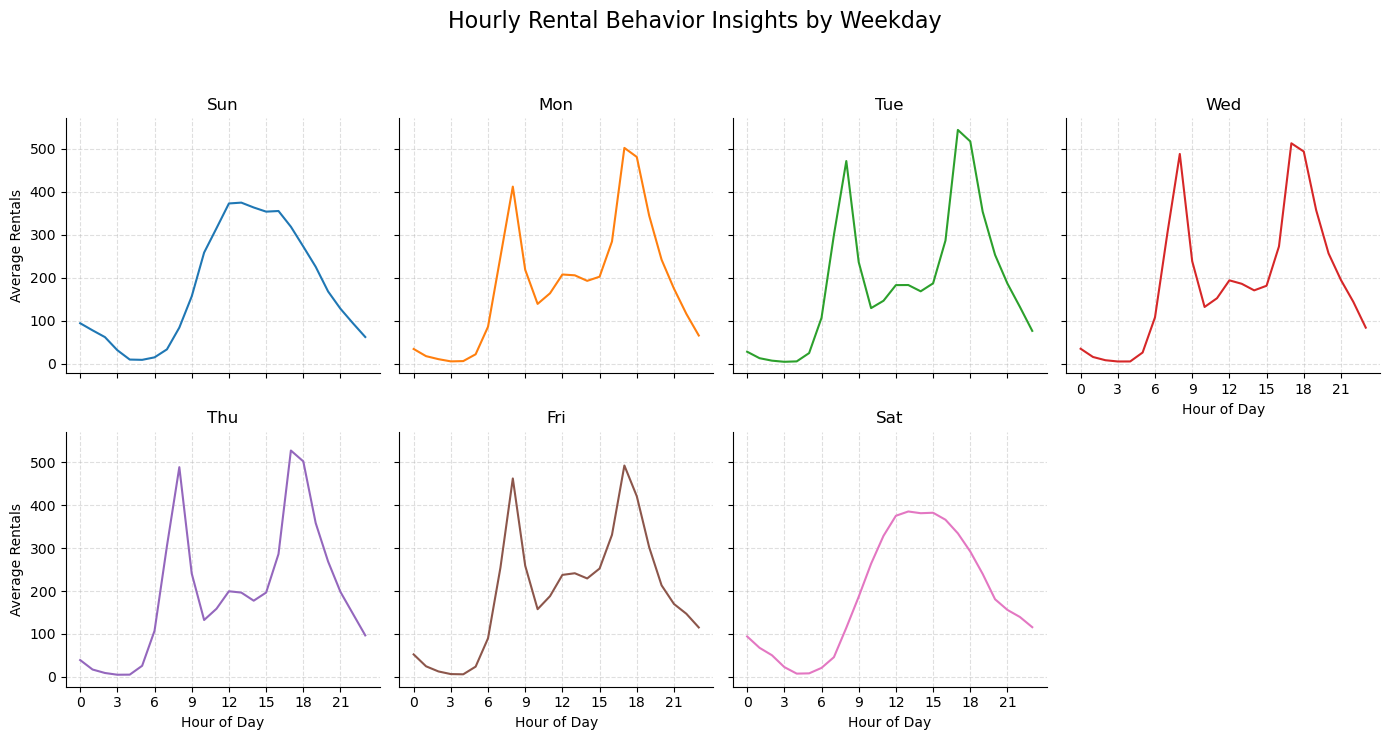

In [16]:
hourly_trend = hour_df.groupby(['weekday', 'hr'])['cnt'].mean().reset_index()

weekday_map = {0:  'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
hourly_trend['weekday_name'] = hourly_trend['weekday'].map(weekday_map)

# set the dates
ordered_days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
hourly_trend['weekday_name'] = pd.Categorical(hourly_trend['weekday_name'], categories=ordered_days, ordered=True)


palette = sns.color_palette("tab10", 7)
color_dict = dict(zip(ordered_days, palette))


g = sns.FacetGrid(hourly_trend, col='weekday_name', col_wrap=4, height=3.5, sharey=True)

for ax, day in zip(g.axes.flatten(), ordered_days):
    day_data = hourly_trend[hourly_trend['weekday_name'] == day]
    sns.lineplot(data=day_data, x='hr', y='cnt', ax=ax, color=color_dict[day])
    ax.set_title(day)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([str(h) for h in range(0, 24, 3)])
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Rentals')
    ax.grid(True, linestyle ='--', alpha=0.4)


g.fig.suptitle('Hourly Rental Behavior Insights by Weekday', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

= The plot reveals distinct hourly rental patterns across weekdays, with commute-time peaks on weekdays and afternoon peaks on weekends. These insights highlight the importance of using both weekday and hour as key features in demand forecasting and operational planning.

**Weekdays** (Mon–Fri):
   
    Two strong peaks
    
    - 8 AM: Morning commute
    - 5–6 PM (17–18 hrs): Evening commute
    - The pattern is consistent across all weekdays, indicating that many users rely on bike rentals as part of their daily work or school routine

**Weekends** (Sat–Sun):
    
    - A broad peak from 11 AM to 4 PM (11–16 hrs).
    - This suggests that weekend rentals are more leisure-oriented, with users likely riding for relaxation or recreation rather than commuting.

**Why This Matters**
- Understanding hourly demand by weekday helps optimize:


      -  Bike redistribution during peak hours
      -  Staffing and maintenance schedules
      -  Marketing strategies based on user intent(commuting vs leisure)



### 2. Histogram Plots

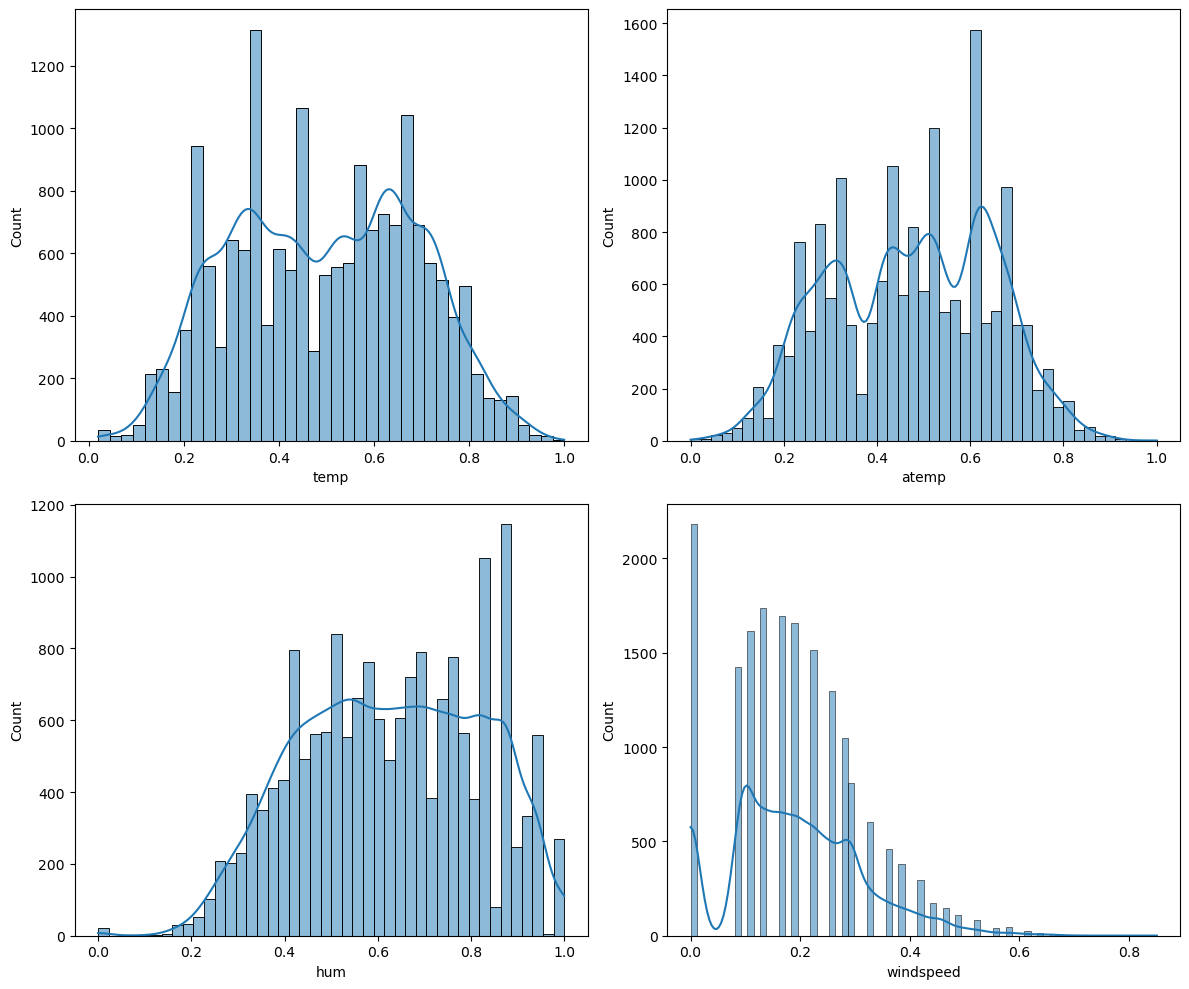

In [17]:
# Distribution of Temperature, Feeling Temperature, Humidity, Windspeed

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(hour_df['temp'], ax=axes[0, 0], kde=True)
sns.histplot(hour_df['atemp'], ax=axes[0, 1], kde=True)
sns.histplot(hour_df['hum'], ax=axes[1, 0], kde=True)
sns.histplot(hour_df['windspeed'], ax=axes[1, 1], kde=True)

plt.tight_layout()
plt.show()

= The histograms display the distributions of temp, atemp, hum, and windspeed, with kernel density estimates overlaid. Both temperature features exhibit approximately normal distributions, while humidity and windspeed show skewness towards higher and lower values, respectively. These visualizations help identify feature scaling, potential outliers, and distributional characteristics relevant for model selection and preprocessing.

**1. Normalized Temperature** - Bimodal distribution with two prominent peaks at 0.35 and 0.6.

- Suggests frequent use in mild to warm temperatures.

- Few very cold (<0.2) and hot (>0.8) temperature measurements.

- The majority of rentals take place in acceptable temperatures, neither chilly nor hot.


**2. atemp (Feeling Temperature)**
- The distribution is comparable to temperature, but significantly smoother.

- More uniform over the mid-range temperatures, which is appropriate for a "feels like" metric.

- Rental behavior is consistent when temperatures are thought to be comfortable.

**3. Humidity** - Distribution is slightly biased to the right.

- Most humidity levels range between 0.5 and 0.9.

- Low readings in extremely dry conditions (<0.2).

- Rentals occur in environments with moderate to high humidity. Extremely low humidity is rare or not recorded.

**4. Windspeed** - Strongly right-skewed (long tail to the right).

- Most values fall between 0.0 and 0.2.

- There have been very few observations of high wind speeds.

- The technique is most usually employed when winds are light to moderate. High winds may inhibit riding or be unusual.


**Why This Matters**
- Understanding the distribution of continuous features such as temperature, humidity, and windspeed is essential for effective feature engineering and preprocessing.

- These histograms reveal non-normality, skewness, and potential outliers, which inform decisions on scaling methods (e.g., standardization, normalization) and transformation techniques (e.g., log or Box-Cox).

- The insights also help assess model suitability. for example, models assuming normality may underperform on skewed features.

- Moreover, these distributions reflect real-world user behavior patterns such as the tendency to avoid biking in extreme temperatures or high wind which can guide feature selection and model interpretation.



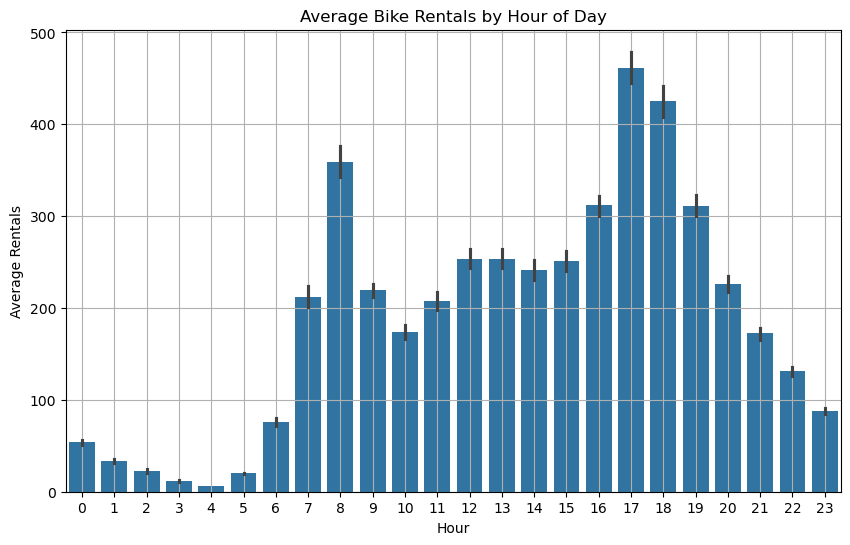

In [18]:
# Bike Rentals by Hour of Day

plt.figure(figsize=(10, 6))
sns.barplot(x='hr', y='cnt', data=hour_df, estimator=np.mean)
plt.title('Average Bike Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

= The bar plot illustrates the average bike rentals across different hours of the day. This pattern highlights the influence of daily routines on bike rental demand and supports feature engineering related to time-of-day effects for predictive modeling.

- Bike rentals peak during typical commuting hours (8 AM and 5–6 PM), confirming heavy use for work/school travel.

- Moderate midday usage suggests potential for leisure or flexible travel users during non-peak hours.

- Low usage at early morning and night indicates limited demand for rentals.

**Why This Matters**

- This visualization reveals strong time-of-day effects in rental behavior, emphasizing the importance of hour-based features for temporal modeling.

- Clear peaks during commuting hours support the inclusion of commute indicators (e.g., rush hour flags) in predictive models.

- The distinct off-peak and night-time patterns help in resource optimization, such as bike redistribution and station staffing.

- These patterns also reflect user intent segmentation (e.g., commuters vs. leisure users), which can enhance personalization and marketing strategies.


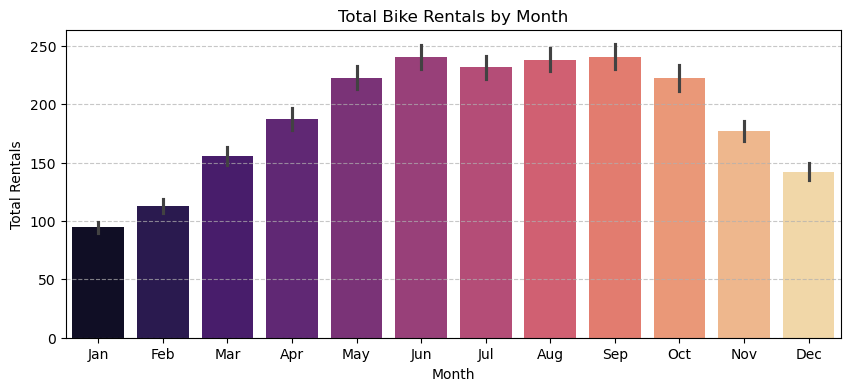

In [19]:
#  Map month numbers to names
hour_df['month_name'] = hour_df['mnth'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep',10:'Oct',11:'Nov',12:'Dec'
})

# Plot with month names
plt.figure(figsize=(10, 4))
sns.barplot(data=hour_df, x="month_name", y="cnt", palette="magma")
plt.title("Total Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Total Rentals")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

= The bar plot shows total bike rentals aggregated by month, revealing a clear seasonal trend. Rentals increase steadily from March and peak between June and September, followed by a decline in late autumn and winter. This pattern reflects higher demand during warmer months and supports the inclusion of seasonal indicators in predictive models.

**Increasing trend from January to June:**

- Rentals start low in January, averaging under 100 per hour, and steadily increase through spring.

- By June, hourly rentals surpass 200, indicating seasonal demand growth as weather improves.



**High, stable rentals from June to September:**

- Rentals remain consistently high in June, July, August, and September.

- Indicates strong demand during summer months due to favorable weather and increased outdoor activities.

**Decline from October to December:**

- Rentals decrease gradually from October (180/ hour) to December (110/hour).

- Reflects lower usage during colder, darker months.

**Why This Matters**
- The seasonal pattern underscores the impact of weather and daylight on user behavior, validating the inclusion of month or season as features in modeling.

- Understanding peak and off-peak months helps optimize resource allocation, maintenance cycles, and marketing strategies.

- It enables data-driven forecasting that adjusts for seasonal fluctuations in demand.



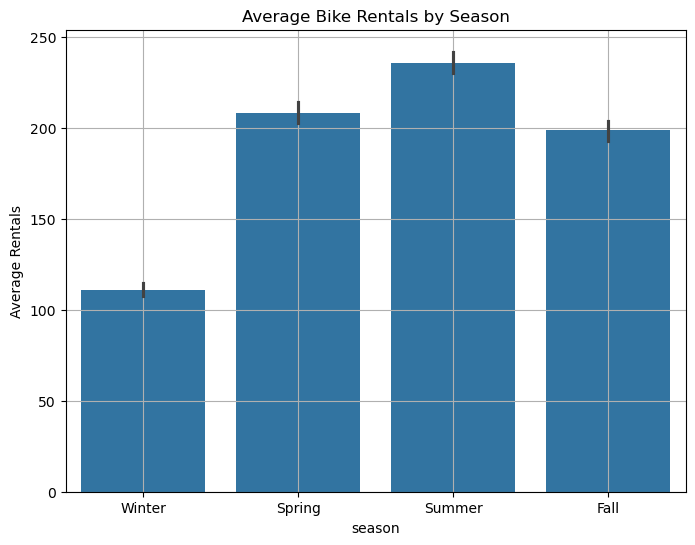

In [20]:
# Rentals by Season

plt.figure(figsize=(8, 6))
sns.barplot(x='season', y='cnt', data=hour_df, estimator=np.mean)
plt.title('Average Bike Rentals by Season')
plt.xticks(ticks=[0,1,2,3], labels=['Winter', 'Spring', 'Summer', 'Fall'])
plt.ylabel('Average Rentals')
plt.grid(True)
plt.show()

= The bar plot illustrates average bike rentals across seasons. This seasonal variation highlights the influence of weather and daylight on user behavior, indicating the importance of including seasonal indicators in predictive modeling.


**Lowest rentals in Winter:**
- Average rentals are lowest in Winter, around 110, reflecting cold temperatures and reduced daylight.
- Suggests users are less likely to bike in unfavorable weather.

**Rise in Spring and Peak in Summer:**
- Rentals rise sharply in Spring to around 210, indicating improved weather conditions.
- Summer sees the highest average rentals, around 235, driven by long, warm, and dry days — ideal for biking.

**Slight Decline in Fall:**

- Rentals slightly drop in Fall to around 200, but remain high.
- Suggests that even with cooling temperatures, user demand is still strong.

**Overall insights:**

- Bike rentals are highest during Summer and Spring, reflecting seasonal trends and outdoor-friendly weather.
- Winter sees the lowest demand, while Fall maintains relatively high usage.

**Why This Matters**

- This seasonal trend visualization emphasizes the strong influence of climate and daylight on user behavior, making seasonality a critical factor in demand forecasting.

- Recognizing peak rental periods in summer and fall helps with capacity planning, maintenance scheduling, and marketing efforts aligned with high-demand seasons.

- The data also supports the inclusion of seasonal dummy variables or weather-related features in predictive models to improve accuracy.

Understanding that rentals remain moderate even in winter suggests a steady base demand, which is useful for ensuring year-round service continuity.

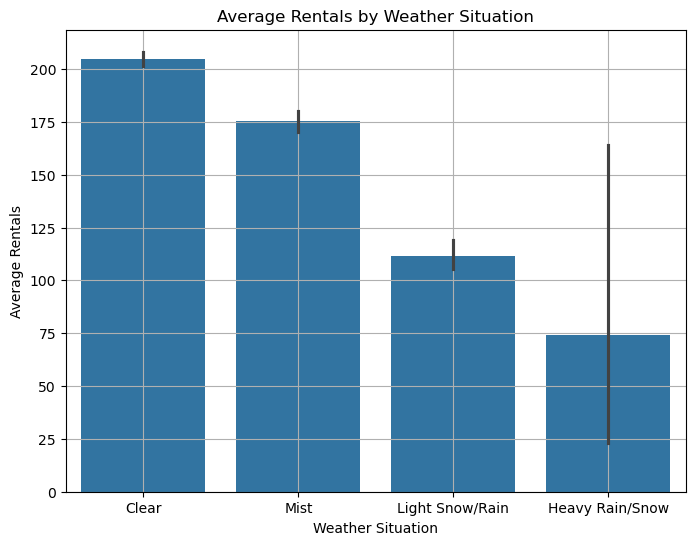

In [21]:
# Rentals by Weather Situation

plt.figure(figsize=(8, 6))
sns.barplot(x='weathersit', y='cnt', data=hour_df, estimator=np.mean)
plt.title('Average Rentals by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average Rentals')
plt.xticks(ticks=[0,1,2,3], labels=['Clear','Mist','Light Snow/Rain','Heavy Rain/Snow'])
plt.grid(True)
plt.show()

= The bar plot shows average bike rentals across different weather conditions. This pattern highlights weather as a key factor influencing demand and supports its inclusion as a predictive feature.

**Highest rentals in clear weather:**

- Rentals are highest ~205 on clear days, indicating favorable weather encourages bike usage.

**Slight drop during mist:**

- Rentals decrease slightly ~175 but remain relatively high during misty conditions, showing users still ride when weather is mild.

**Significant drop during light snow/rain:**

- Rentals drop further ~110, reflecting users avoid riding in light precipitation.

**Lowest rentals during heavy rain/snow:**

- Rentals drop sharply ~75, showing poor weather significantly reduces bike usage.
- Large error bars indicate higher variability in rentals during heavy weather conditions.

**Overall insights:**

- Weather significantly impacts bike rentals, with clear weather yielding the highest rentals and usage dropping sharply as weather worsens, especially during heavy rain or snow.

**Why This Matters**
- This graph clearly demonstrates that weather conditions are a strong determinant of user behavior, making weather-related features essential in demand forecasting models.

- The sharp decline in rentals under poor weather (snow/rain) highlights the need for weather-adjusted inventory planning, such as reducing bike redistribution efforts on days with forecasted storms.

- The variability observed under heavy conditions suggests greater uncertainty in user behavior, which can be accounted for through probabilistic modeling or scenario analysis.

- Including weather as a predictive feature enhances model responsiveness to real-world conditions and improves overall forecasting accuracy


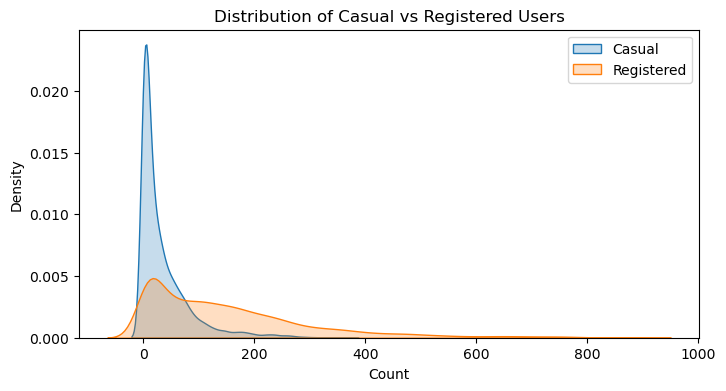

In [22]:
plt.figure(figsize=(8,4))
sns.kdeplot(hour_df["casual"],label ="Casual",shade=True)
sns.kdeplot(hour_df["registered"],label ="Registered",shade=True)
plt.title("Distribution of Casual vs Registered Users")
plt.xlabel("Count")
plt.ylabel("Density")
plt.legend()
plt.show()

= The KDE plot compares the distributions of hourly bike rental counts between casual and registered users. This distinction highlights different behavioral patterns and emphasizes the need to consider potential data leakage when selecting features for modeling.

**Casual users:**
- Most hourly rental counts cluster between 0–100, peaking sharply around 30–50.
- The distribution shows a steep drop-off after 150–200, with very few high-usage hours.
- This pattern suggests infrequent or spontaneous usage, often influenced by weather or weekends, likely from tourists or one-time users.


**Registered users:**
- Rental activity is more spread out, with a longer tail toward higher counts.
- Most registered user rentals fall between 100–400, with a peak around 250–300.
- This reflects routine usage, likely from commuters or regular riders, and suggests strong engagement with the platform.


**Overall insights:**
- Registered users dominate the platform’s daily activity with consistent and higher rental volumes.
- Casual users contribute less frequently but represent a potential growth opportunity if targeted for conversion.

**Why This Matters:**
- Understanding these patterns enables more tailored predictive models, possibly treating casual and registered behaviors separately.
- Helps guide marketing strategies, such as:
    - Converting casual users to registered ones.
    - Offering promotions during low-usage hours.
- Also supports operational planning, like allocating more bikes during peak hours for registered users

### 3. Box Plots

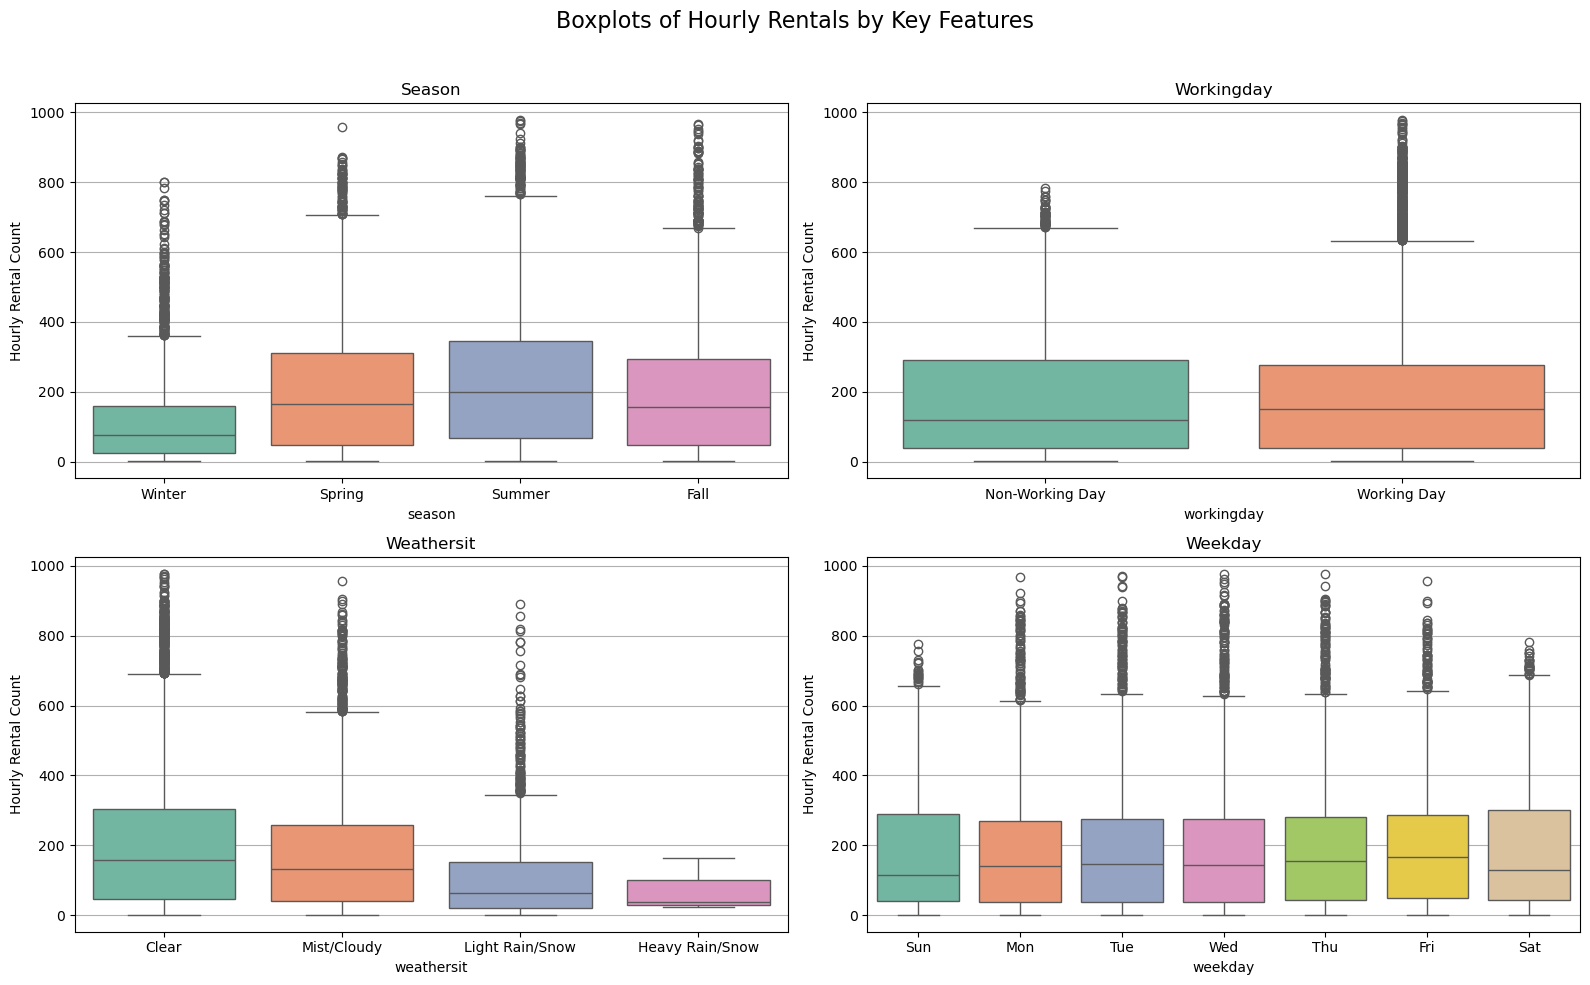

In [23]:
# Recreate the 2x2 boxplot layout without annotations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Feature definitions
features = ['season', 'workingday', 'weathersit', 'weekday']
feature_labels = {
    'season': ['Winter', 'Spring', 'Summer', 'Fall'],
    'workingday': ['Non-Working Day', 'Working Day'],
    'weathersit': ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow'],
    'weekday': ['Sun','Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
}

# Generate all 4 boxplots
for idx, feature in enumerate(features):
    sns.boxplot(data=hour_df, x=feature, y='cnt', palette='Set2', ax=axes[idx])
    if feature in feature_labels:
        axes[idx].set_xticks(range(len(feature_labels[feature])))
        axes[idx].set_xticklabels(feature_labels[feature])
    axes[idx].set_title(feature.capitalize())
    axes[idx].set_ylabel('Hourly Rental Count')
    axes[idx].grid(axis='y')

plt.suptitle('Boxplots of Hourly Rentals by Key Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


= The boxplots visualize hourly rental distributions across season, working day status, weather situation, and weekday.

**1. Season**: Fall and summer have the biggest rental activity.

 - Winter has the lowest utilization.

 - Summer utilization is moderate, but highly variable.

 Conclusion: Rentals are most popular in the Summer and Spring, while Winter trails behind.

**2. Working Day**: Rentals are more consistent during working days.

 - Non-working days exhibit greater volatility and more outliers.

 Conclusion: Commuting drives consistent demand on weekdays, while leisure creates fluctuations on weekends.

**3. Weather Situation**: Clear skies result in higher and more stable rentals.

 - Clouds and mild rain diminish and shift demand.

 - Severe weather nearly prevents utilization.

 Conclusion: Good weather is essential for high and predictable rents.

**4. Weekday**: Commuter habits are stable from Monday to Friday.

 - Saturday and Sunday feature greater unpredictability and higher peaks.

 Conclusion: Weekdays indicate routine use, but weekends provide sporadic but frequently strong demand.

**Why This Matters**
- These boxplots reveal how key categorical features (season, working day, weather, and weekday) impact the distribution of hourly bike rentals, offering essential insights for feature selection and model interpretability.

- By showing both central trends and variability, the plots help identify which features influence rental volume the most and where outliers and volatility occur.

- For example, the contrast between stable weekday demand and volatile weekend usage suggests different user intent—commuting vs. leisure—which can guide user segmentation and targeted strategy development.

- The visualization also highlights how weather and calendar features affect rental consistency, supporting the use of these variables in predictive modeling, scenario analysis, and business planning.

- Overall, it provides a multidimensional view of how environmental and temporal factors interact with bike rental behavior, improving both data understanding and model design.

### 4. Pie Charts

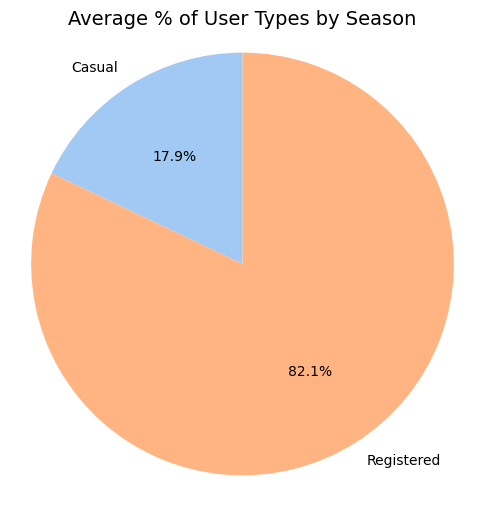

In [24]:
season_user = hour_df.groupby('season')[['casual', 'registered']].sum()
season_percent = season_user.div(season_user.sum(axis=1), axis=0) * 100
avg_percent = season_percent.mean()
user_type_labels = ['Casual', 'Registered']


plt.figure(figsize=(6, 6))
plt.pie(
    avg_percent,
    labels=user_type_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Average % of User Types by Season', fontsize=14)
plt.axis('equal')
plt.show()



= The visualizations illustrate total bike rentals by the average proportion of user types.

**Average % of User Types by Season**
- On average, **registered users make up 82.1%** of rentals.
- Casual users contribute around **18%%**, with slight increases in warmer months.

**Why this matters:**

Understanding the seasonal average user distribution is crucial for segmentation strategies and targeted engagement. Since registered users drive the bulk of usage year-round, promotional efforts may focus on retention and loyalty for this group. On the other hand, season-specific promotions (e.g., summer events) could help convert casual users into more frequent riders. This insight also helps in forecasting demand by user type and designing seasonal resource allocation accordingly.

### 5. Donut Charts

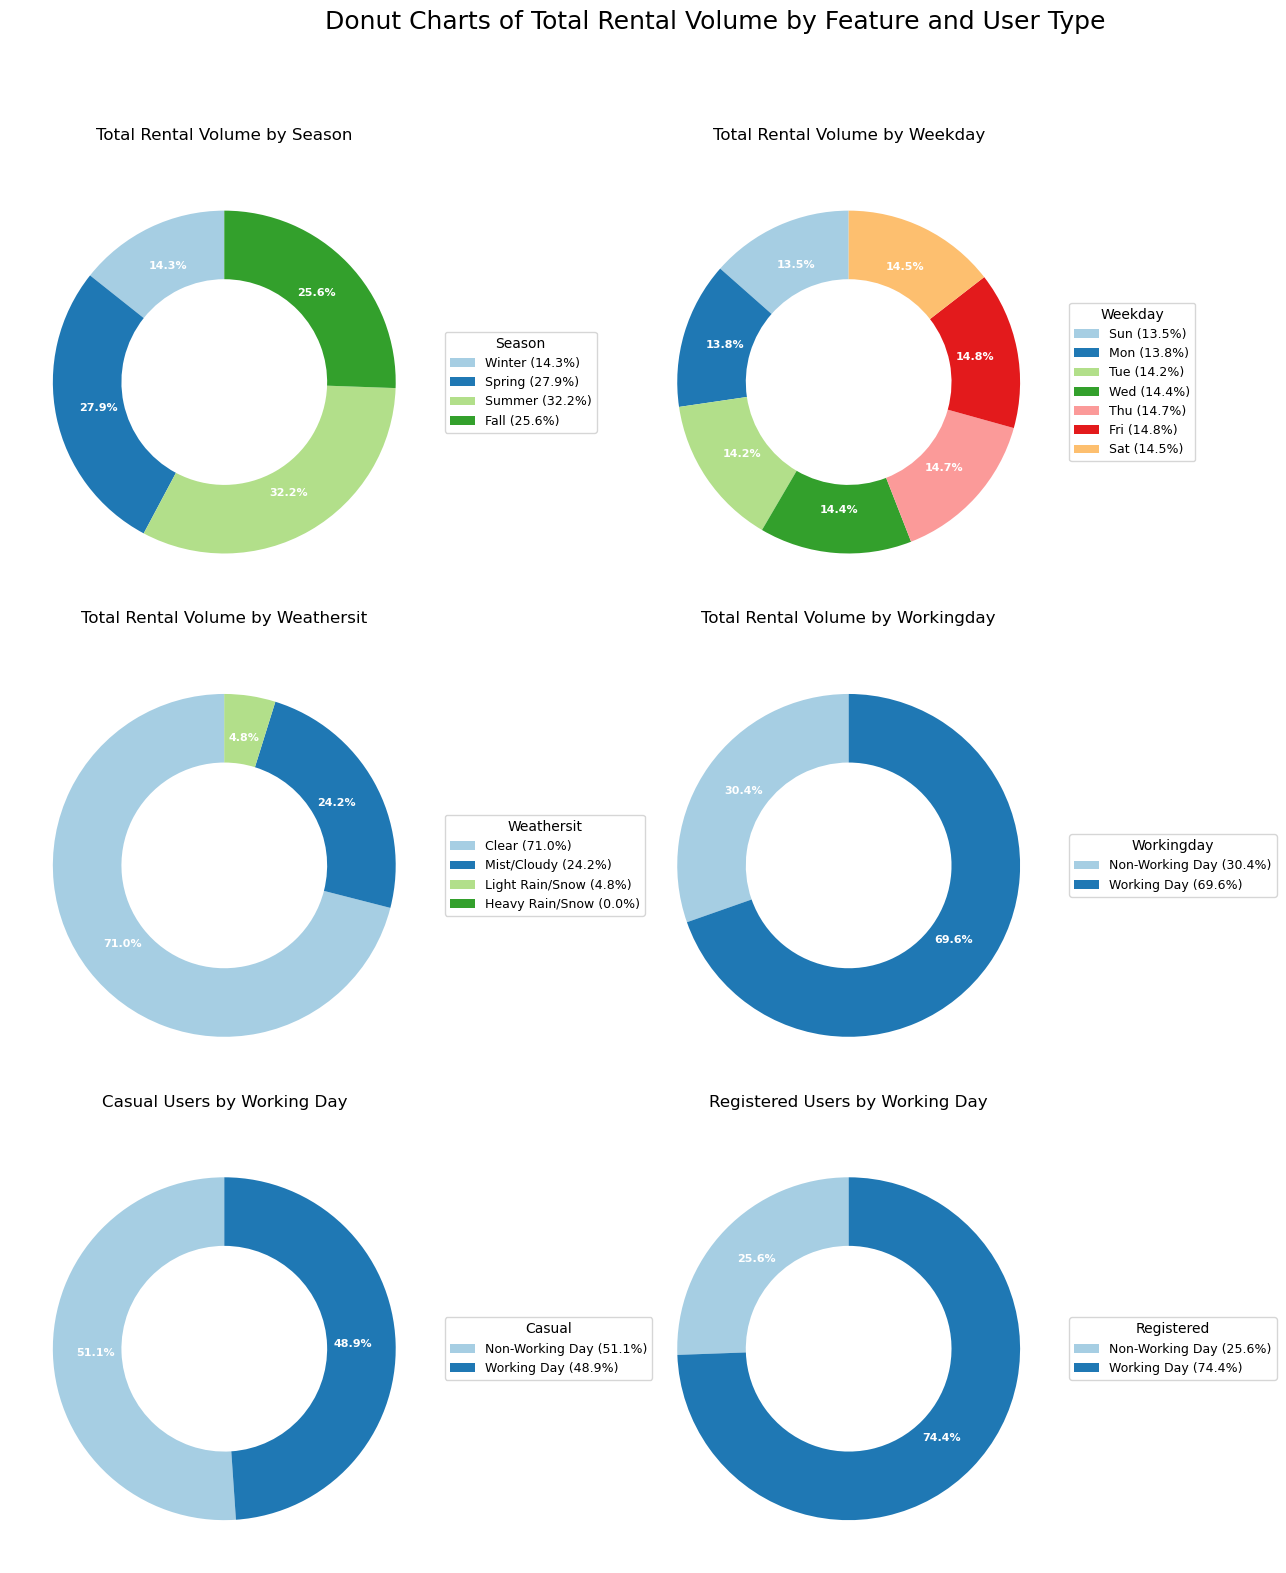

In [25]:
volume_data = {
    'season': hour_df.groupby('season')['cnt'].sum(),
    'weekday': hour_df.groupby('weekday')['cnt'].sum(),
    'weathersit': hour_df.groupby('weathersit')['cnt'].sum(),
    'workingday': hour_df.groupby('workingday')['cnt'].sum()
}

# workingday- casual / registered
workingday_split = {
    'casual': hour_df.groupby('workingday')['casual'].sum(),
    'registered': hour_df.groupby('workingday')['registered'].sum()
}

labels_dict = {
    'season': ['Winter', 'Spring', 'Summer', 'Fall'],
    'weekday': ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'],
    'weathersit': ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow'],
    'workingday': ['Non-Working Day', 'Working Day'],
    'casual': ['Non-Working Day', 'Working Day'],
    'registered': ['Non-Working Day', 'Working Day']
}

paired_colors = sns.color_palette('Paired')

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

features = ['season', 'weekday', 'weathersit', 'workingday']
for ax, feature in zip(axes.flat[:4], features):
    values = volume_data[feature].sort_index()
    labels = labels_dict[feature][:len(values)]
    
    # Filter out very small slices to avoid overlap
    percentages = [v/sum(values)*100 for v in values]
    wedges, texts, autotexts = ax.pie(values, labels=None, autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '', 
                                     startangle=90, wedgeprops=dict(width=0.4), 
                                     colors=paired_colors[:len(labels)],
                                     pctdistance=0.75)
    
    # Improve percentage text formatting
    for autotext in autotexts:
        if autotext:  # Check if autotext exists
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)
    
    ax.set_title(f'Total Rental Volume by {feature.capitalize()}', pad=20)
    
    # Add legend with percentages
    legend_labels = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]
    ax.legend(wedges, legend_labels, title=feature.capitalize(), loc="center left", 
              bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

for ax, user_type in zip(axes.flat[4:], ['casual', 'registered']):
    values = workingday_split[user_type].sort_index()
    labels = labels_dict[user_type]
    
    # Calculate percentages for legend
    percentages = [v/sum(values)*100 for v in values]
    wedges, texts, autotexts = ax.pie(values, labels=None, autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
                                     startangle=90, wedgeprops=dict(width=0.4), 
                                     colors=paired_colors[:2],
                                     pctdistance=0.75)
    
    # Improve percentage text formatting
    for autotext in autotexts:
        if autotext:  # Check if autotext exists
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)
    
    ax.set_title(f'{user_type.capitalize()} Users by Working Day', pad=20)
    
    # Add legend with percentages
    legend_labels = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]
    ax.legend(wedges, legend_labels, title=user_type.capitalize(), loc="center left", 
              bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

plt.suptitle('Donut Charts of Total Rental Volume by Feature and User Type', fontsize=18)
plt.tight_layout(rect=[0, 0, 0.85, 0.94])
plt.show()

= The donut charts summarize total rental volumes across season, weekday, weather condition, and working day status. Clear trends are observed, such as higher rentals in fall and summer, a strong preference for clear weather, and substantial activity on working days. These patterns provide critical insights into user behavior and environmental influences, supporting feature selection and informing predictive model development.

**Season**
- Summer (32%) and Spring (28%) dominate in total rentals.

- Winter lags behind with just 14% of total usage.

**Weekday**
- Even distribution across all days (13–15%).

- weekdayshave slightly higher shares than Weekends.

**Weather Situation**
- Clear weather = 71% of total rentals.
- Mist/cloudy at 24%, and almost no usage during heavy weather.

**Working Day**
- Working days = 70% of total rental volume.

- Commuter behavior is strong and consistent.

**Casual Users by Working Day**
- Casual users rent more on non-working days (weekends and holidays).

**Registered Users by Working Day**
- Majority of rentals happen on working days, consistent with commuting behavior.
- Shows high weekday engagement among subscribers.

**Why this matters**

These charts offer clear evidence that seasonality, weather, and working day status strongly influence rental volume. Additionally, the distinct patterns between casual and registered users emphasize the need to consider user types separately in modeling. This insight supports the development of tailored prediction strategies and enhances the accuracy of demand forecasting models by identifying which features drive consistent vs. variable usage behavior.


### 6. Correlation Analysis

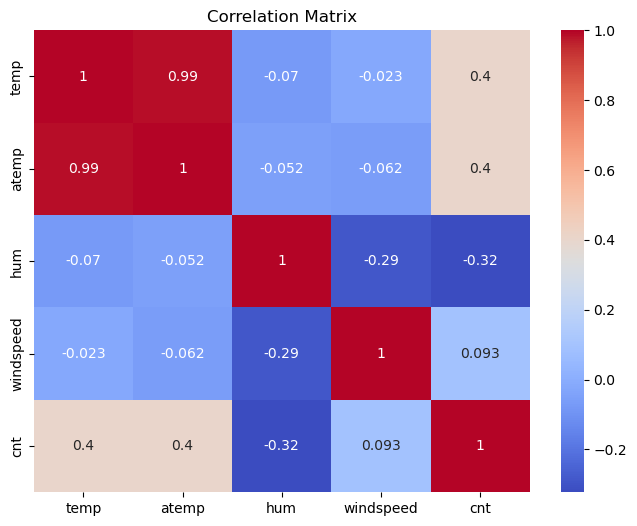

In [26]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr = hour_df[numeric_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

= The correlation matrix highlights relationships between numerical features and the target variable (cnt). Moderate positive correlation is observed between temperature variables (temp, atemp) and user count, while humidity shows a moderate negative correlation. Windspeed exhibits minimal correlation with user count. These findings support prioritizing temperature and humidity as key predictors in model development.

- Temperature (temp, atemp) has a moderate positive correlation (0.4) with user count (cnt), indicating higher temperatures increase user activity.

- Humidity (hum) has a moderate negative correlation (-0.32) with user count, suggesting higher humidity decreases user activity.

- Windspeed has a very weak correlation (0.09) with user count, showing minimal impact.

**Why This Matters**

- Identify multicollinearity: Highly correlated features (e.g., temp vs atemp) can distort model coefficients in linear models and should be handled (e.g., drop one).

- Select relevant predictors: Features that correlate well with the target (cnt) are useful in predictive modeling.

- Improve model performance: Removing or combining redundant features simplifies the model and may reduce overfitting.

- Guide feature engineering: Weakly or uncorrelated variables might require transformation or can be deprioritized.


# III. Data Cleaning

In [27]:
# Make a clean copy before any changes
hour_df_cleaned = hour_df.copy()

day_df_cleaned = day_df.copy()

In [28]:
# Customize Dataframe function
def summarize_df(df):

    # Total number of rows
    total_rows = len(df)

    # Missing values and percentage
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / total_rows) * 100

    # Describe numerical columns only
#     desc = df.describe().T  # Transpose for easier alignment

    # Combine everything into one DataFrame
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Count': df.count(),
#         'mean': desc['mean'],
#         'std': desc['std'],
#         'min': desc['min'],
#         'max': desc['max'],
        'Missing Count': missing_count,
        'Missing (%)': round(missing_percent, 2)
    })

    print(summary)

= This function summarize_df(df) was created to provide a quick overview of the dataset’s structure and quality before performing cleaning and preprocessing steps. It serves multiple purposes:

Check Dataset Integrity:
- Calculates the total number of rows.
- Checks for missing values and reports both the count and percentage per column.

Review Data Types and Counts:
- Displays data types of all columns.
- Shows non-null counts to detect columns with incomplete data.

Optional Statistical Summary (Commented):
- The lines for mean, standard deviation, min, and max are commented out to simplify output, but can be activated if a numerical overview is needed.

Ease of Interpretation:
- Combines metadata and quality checks into one concise table, making it easier to assess readiness for data cleaning.

## A. Removing Irrelevant Columns

We will drop following variables:


In [29]:
hour_df_cleaned.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'datetime', 'year', 'dayofyear', 'month',
       'month_name'],
      dtype='object')

= The listed variables are identified for removal as they provide redundant or non-predictive information. Columns such as instant, dteday, and datetime serve as identifiers rather than features, while casual and registered are components of the target variable and may cause data leakage. This step ensures the dataset contains only relevant features for modeling.

In [30]:
# Drop columns not needed for modeling
hour_df_cleaned.drop(['instant', 'month_name', 'mnth', 'yr', 'holiday', 'datetime' ], axis=1, inplace=True)

= The columns instant, month_name, mnth, yr, holiday, and datetime were removed as they are either identifiers or redundant temporal features. Their exclusion prevents potential noise and simplifies the dataset, ensuring only relevant predictors remain for modeling.

In [31]:
day_df_cleaned.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'datetime'],
      dtype='object')

= Reviewing the column list provides an overview of all features currently in the dataset, including numerical, categorical, and derived variables such as month_name, casual_percent, and registered_percent. This step helps identify redundant or non-predictive features and supports informed decisions for feature selection and data cleaning.

In [32]:
# Drop columns not needed for modeling
day_df_cleaned.drop(['instant', 'mnth', 'yr', 'holiday', 'datetime' ], axis=1, inplace=True)

= The columns instant, mnth, yr, and holiday were removed because they are either identifiers, redundant representations of time, or less relevant for predictive modeling. This step reduces dimensionality and eliminates features that do not contribute meaningfully to model performance.

## B. Renaming and Adjusting Column Data Types

In [33]:
hour_df_cleaned.rename(columns={"dteday" : "date","cnt" : "count"}, inplace = True)

hour_df_cleaned.columns

Index(['date', 'season', 'hr', 'weekday', 'workingday', 'weathersit', 'temp',
       'atemp', 'hum', 'windspeed', 'casual', 'registered', 'count', 'year',
       'dayofyear', 'month'],
      dtype='object')

= Columns dteday and cnt were renamed to date and count for improved clarity and consistency. Clear and descriptive naming enhances readability and reduces ambiguity during data analysis and modeling.

In [34]:
hour_df_cleaned.columns = hour_df_cleaned.columns.str.lower()  # Make column names lowercase

= All column names were converted to lowercase to maintain consistency and prevent case-sensitivity issues during data processing. This standardization simplifies future referencing and improves code readability.

In [35]:
day_df_cleaned.rename(columns={"dteday" : "date","cnt" : "count"}, inplace = True)

day_df_cleaned.columns

Index(['date', 'season', 'weekday', 'workingday', 'weathersit', 'temp',
       'atemp', 'hum', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

= The columns dteday and cnt were renamed to date and count to improve clarity and align with standard naming conventions. This enhances readability and ensures consistent reference to key variables throughout the analysis.

In [36]:
day_df_cleaned.columns = day_df_cleaned.columns.str.lower()  # Make column names lowercase

= Column names were converted to lowercase to ensure consistency and avoid potential case-sensitivity issues during analysis. This practice simplifies coding and improves readability, particularly when referencing columns in functions or scripts.

## C. Handling Missing Values

In [37]:
print("\nMissing values in hourly data:\n")
summarize_df(hour_df_cleaned)


Missing values in hourly data:

                 Data Type  Count  Missing Count  Missing (%)
date        datetime64[ns]  17379              0          0.0
season               int64  17379              0          0.0
hr                   int64  17379              0          0.0
weekday              int64  17379              0          0.0
workingday           int64  17379              0          0.0
weathersit           int64  17379              0          0.0
temp               float64  17379              0          0.0
atemp              float64  17379              0          0.0
hum                float64  17379              0          0.0
windspeed          float64  17379              0          0.0
casual               int64  17379              0          0.0
registered           int64  17379              0          0.0
count                int64  17379              0          0.0
year                 int32  17379              0          0.0
dayofyear            int32  17379    

= A summary of the dataset confirms that all columns have 0% missing values. This validation indicates data completeness and eliminates the need for imputation or removal of records due to missing entries. Ensuring no missing data supports reliable feature preparation and modeling.

- Description of Missing data for hour dataset
- No missing values found — nothing to handle

In [38]:
print("\nMissing values in daily data:\n")
summarize_df(day_df_cleaned)


Missing values in daily data:

           Data Type  Count  Missing Count  Missing (%)
date          object    731              0          0.0
season         int64    731              0          0.0
weekday        int64    731              0          0.0
workingday     int64    731              0          0.0
weathersit     int64    731              0          0.0
temp         float64    731              0          0.0
atemp        float64    731              0          0.0
hum          float64    731              0          0.0
windspeed    float64    731              0          0.0
casual         int64    731              0          0.0
registered     int64    731              0          0.0
count          int64    731              0          0.0


= The summary indicates no missing values across all columns in the daily dataset. This ensures data integrity and confirms that no additional cleaning is required to address missing entries. The dataset is ready for further preprocessing and modeling.

- Description of Missing data for day dataset
- No missing values found — nothing to handle

## D. Detecting and Handling Duplicates

In [39]:
# Check for Duplicates and Remove if there is in hour_df and day_df

for name, df in [("Hour", hour_df), ("Day", day_df)]:
    dup_count = df.duplicated().sum()
    print(f"\nDuplicate rows before removal ({name}): {dup_count}")

    # Remove duplicates
    # No duplicates found, so the removal step below is not needed.
    # df_cleaned = df.drop_duplicates()

    # Confirm removal and show shape comparison
    # print(f"Duplicate rows after removal ({name}): {df_cleaned.duplicated().sum()}")
    # print(f"Original shape: {df.shape} --> After removing duplicates: {df_cleaned.shape}")

    # Save cleaned DataFrame back if needed
    # if name == "Hour":
    #     hour_df_cleaned = df_cleaned
    # else:
    #     day_df_cleaned = df_cleaned



Duplicate rows before removal (Hour): 0

Duplicate rows before removal (Day): 0


= The dataset was checked for duplicate rows, and none were found in either the hourly or daily data. As no duplicates exist, no removal was necessary. This step confirms data integrity and ensures the absence of redundant records that could bias analysis or model training.

- Display the number of duplicates before removal.
- Show sample duplicate rows if they exist for inspection.
- If duplicate is observed, remove duplicates while keeping the first occurrence.
- Show dataset shape before and after.

## E. Detecting and Handling Outliers

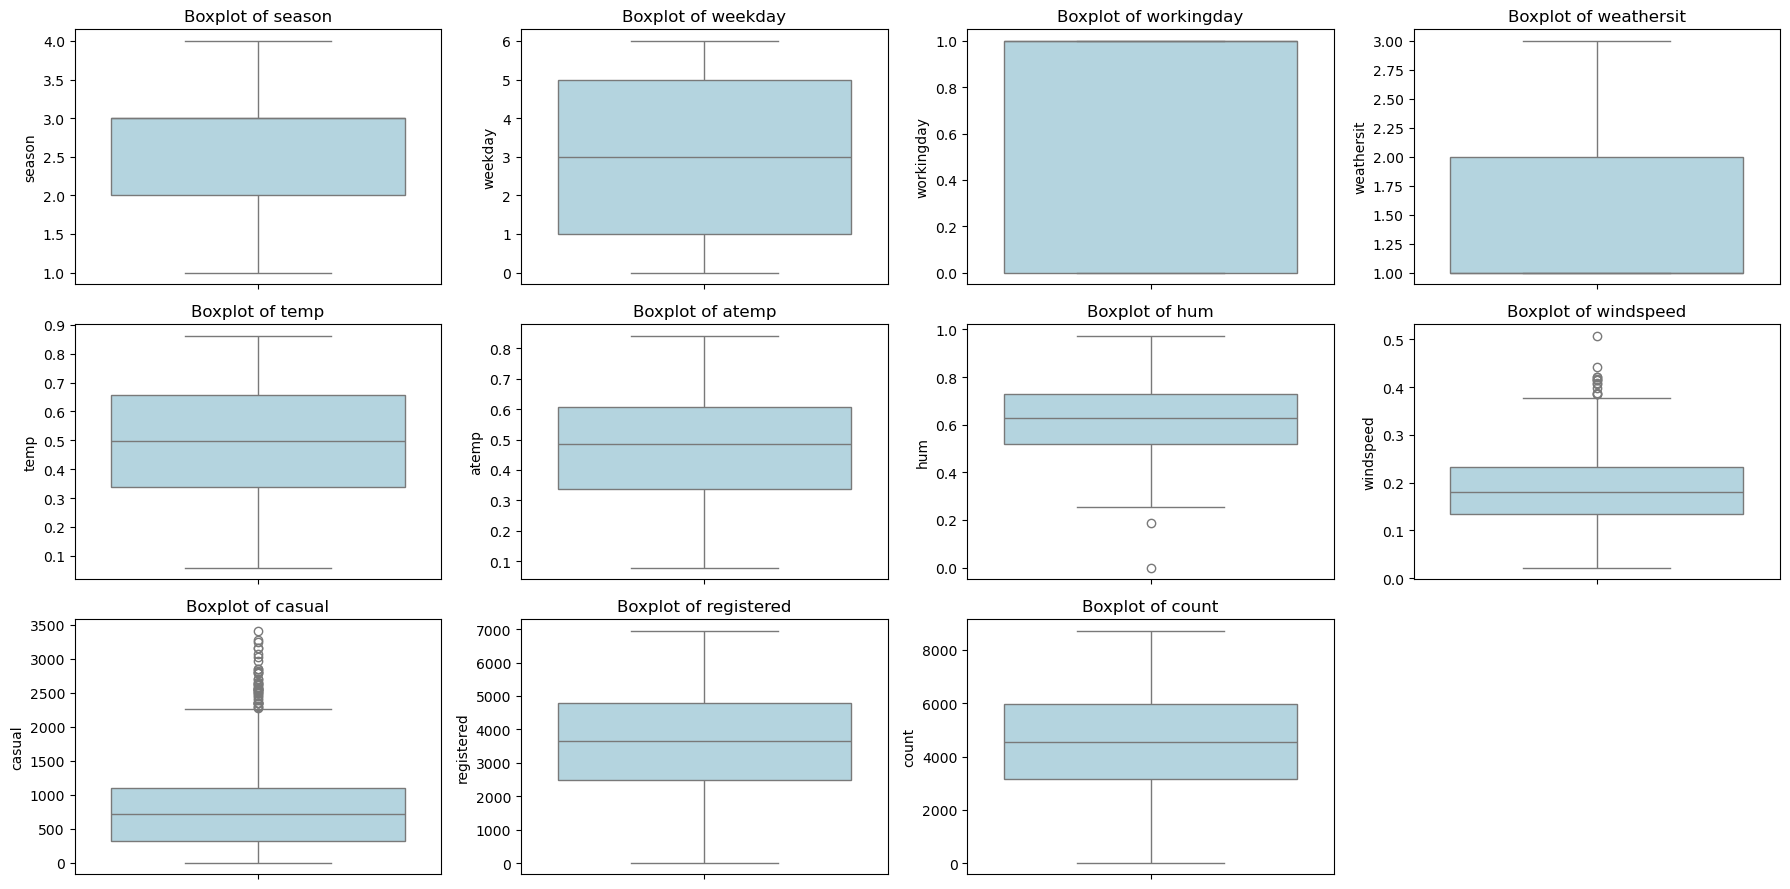

In [40]:
# Select numeric columns only
numeric_columns = day_df_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Set up subplots for boxplots
n_cols = 4
n_rows = int(len(numeric_columns) / n_cols) + 1

plt.figure(figsize=(18, 3 * n_rows))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=day_df_cleaned, y=col, color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


= Boxplots were used to examine numerical features for potential outliers. While most variables exhibit compact distributions, outliers are observed in windspeed, casual, and casual_percent. Identifying these anomalies is essential for assessing their impact on model performance and determining whether mitigation strategies, such as transformation or removal, are necessary.

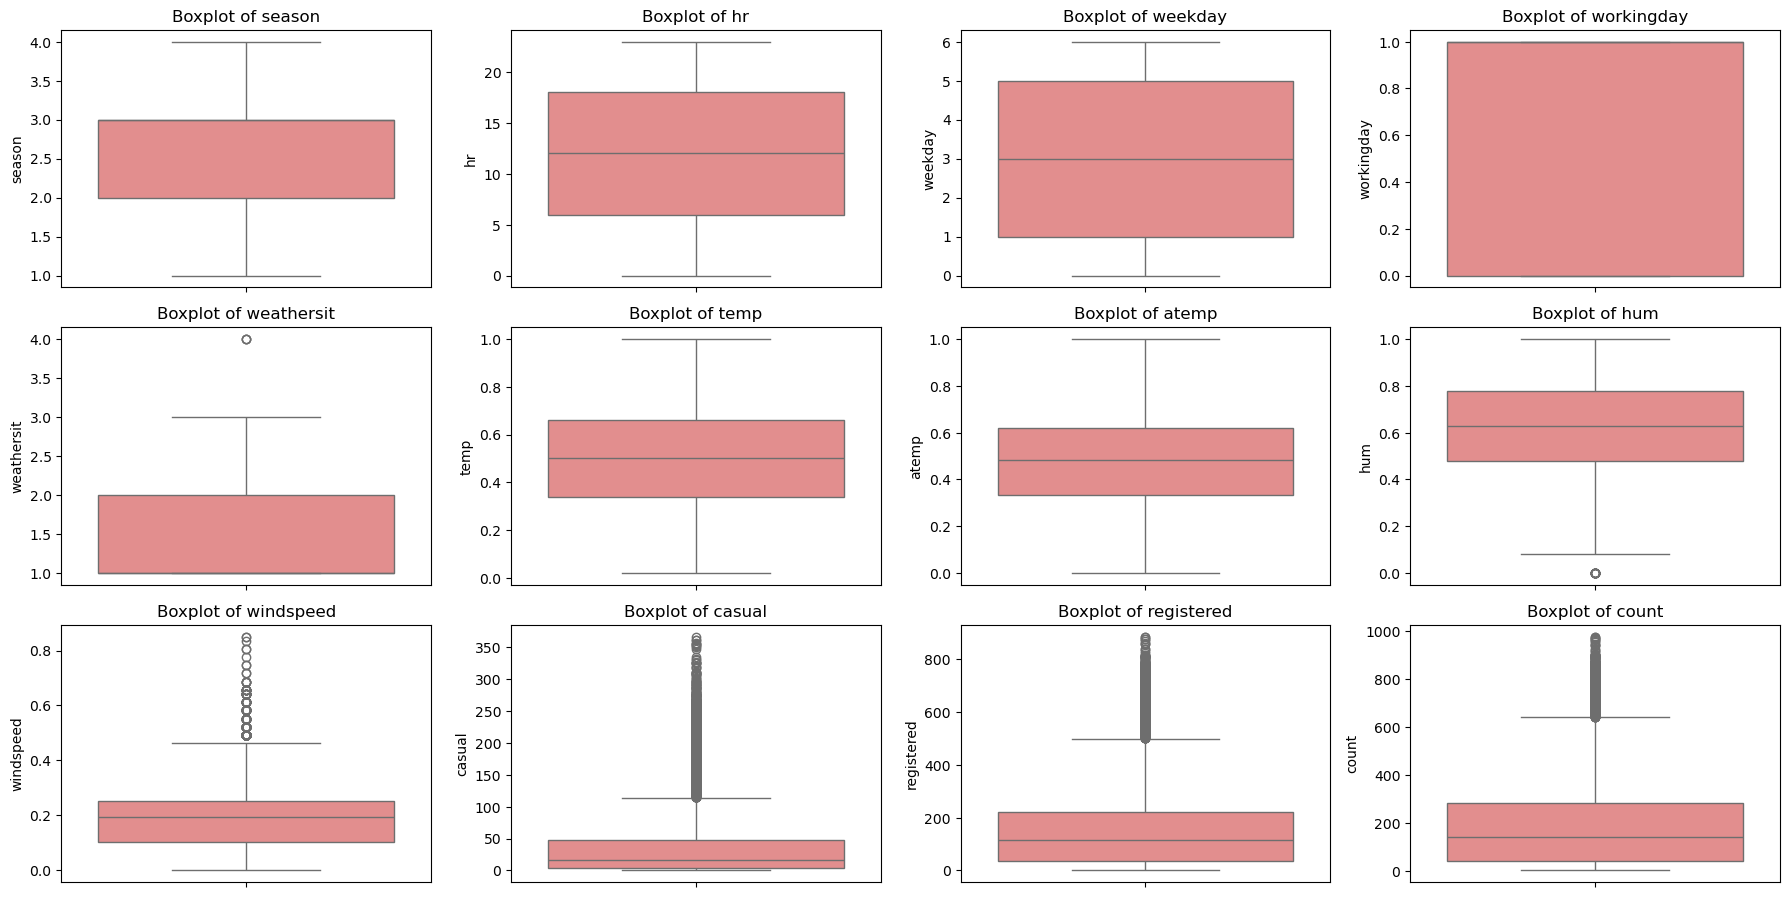

In [41]:
# Select numeric columns
numeric_columns_hour = hour_df_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Set up subplots for boxplots
n_cols = 4
n_rows = int(len(numeric_columns_hour) / n_cols) + 1

plt.figure(figsize=(18, 3 * n_rows))
for i, col in enumerate(numeric_columns_hour, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=hour_df_cleaned, y=col, color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

= Boxplots were generated for numerical features to identify potential outliers. Noticeable outliers are present in windspeed, casual, registered, and count, which may reflect rare events or extreme usage patterns. Recognizing these anomalies is essential to evaluate their impact on model performance and decide whether to retain, transform, or remove them during preprocessing.

In [42]:
# Define a function to remove outliers using the IQR method
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

# Select numeric columns for scaling
day_numeric = day_df_cleaned.select_dtypes(include=['number']).columns.tolist()
hour_numeric = hour_df_cleaned.select_dtypes(include=['number']).columns.tolist()

# Remove outliers before scaling
day_df_cleaned = remove_outliers_iqr(day_df_cleaned, day_numeric)
hour_df_cleaned = remove_outliers_iqr(hour_df_cleaned, hour_numeric)

= The Interquartile Range (IQR) method was applied to identify and remove outliers from numerical features. Values falling outside 1.5 times the IQR were excluded to minimize the influence of extreme observations. This step helps reduce skewness and improves model stability during scaling and training.

# IV. Feature Engineering

## A. Extracting New Useful Columns

In [43]:
# Convert 'date' to datetime (if not already done)
hour_df_cleaned["date"] = pd.to_datetime(hour_df_cleaned["date"])

# Now extract date parts
hour_df_cleaned['day'] = hour_df_cleaned['date'].dt.day
hour_df_cleaned['month'] = hour_df_cleaned['date'].dt.month
hour_df_cleaned['year'] = hour_df_cleaned['date'].dt.year

# drop the original 'date' column if no longer needed
hour_df_cleaned.drop("date", axis=1, inplace=True)

# Show updated DataFrame
hour_df_cleaned.head()

,season,hr,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count,year,dayofyear,month,day
0,1,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011,1,1,1
1,1,1,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011,1,1,1
2,1,2,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011,1,1,1
3,1,3,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011,1,1,1
4,1,4,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011,1,1,1


= The original date column was converted to datetime format and decomposed into separate features: day, month, and year. This transformation enhances the dataset by enabling the model to capture temporal patterns and seasonal trends more effectively. Dropping the original date column avoids redundancy and maintains a clean feature set for analysis.


In [44]:
# Convert 'date' to datetime (if not already done)
day_df_cleaned["date"] = pd.to_datetime(day_df_cleaned["date"])

# Now extract date parts
day_df_cleaned['day'] = day_df_cleaned['date'].dt.day
day_df_cleaned['month'] = day_df_cleaned['date'].dt.month
day_df_cleaned['year'] = day_df_cleaned['date'].dt.year

# drop the original 'date' column if no longer needed
day_df_cleaned.drop("date", axis=1, inplace=True)

# Show updated DataFrame
day_df_cleaned.head()

,season,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count,day,month,year
0,1,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,1,1,2011
1,1,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2,1,2011
2,1,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,3,1,2011
3,1,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,4,1,2011
4,1,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,5,1,2011


= The date column was converted to datetime format and split into day, month, and year to enable temporal analysis. This feature engineering step enhances the dataset by allowing the model to identify seasonal and annual trends in bike rental patterns. The original date column was dropped to avoid redundancy and maintain a streamlined dataset.

## B. Creating New Features

In [45]:
def get_time_of_day(hr):
    if 6 <= hr < 12:
        return 'morning'
    elif 12 <= hr < 17:
        return 'afternoon'
    elif 17 <= hr < 21:
        return 'evening'
    else:
        return 'night'

# Apply the function to 'hr' column
hour_df_cleaned['time_of_day'] = hour_df_cleaned['hr'].apply(get_time_of_day)

= The time_of_day feature was created by grouping hours into categories: morning, afternoon, evening, and night. This transformation captures daily usage patterns more effectively than raw hourly data and supports the model in identifying time-specific demand trends.

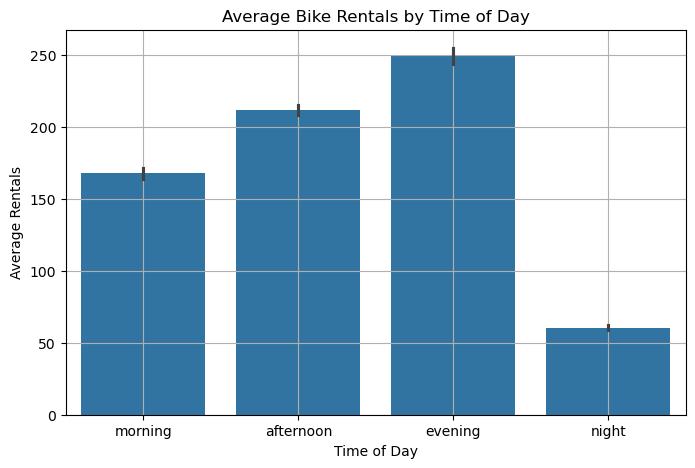

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x='time_of_day', y='count', data=hour_df_cleaned, estimator=np.mean, order=['morning', 'afternoon', 'evening', 'night'])
plt.title('Average Bike Rentals by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Rentals')
plt.grid(True)
plt.show()

= The bar plot illustrates average bike rentals across time-of-day categories. Evening hours show the highest demand, followed by afternoon and morning, while night sees minimal activity. This visualization confirms the relevance of the time_of_day feature for capturing temporal usage patterns and supporting time-aware predictive modeling.

# V. Data Preparation & Preprocessing

## A. Encoding Variables

In [47]:
# One-hot encode weathersit

# Define mapping for weather situations
weathersit_mapping = {
    1: 'clear',
    2: 'mist',
    3: 'light_precipitation',
    4: 'heavy_precipitation'
}

# Apply mapping to weathersit column to create new feature
hour_df_cleaned['weather'] = hour_df_cleaned['weathersit'].map(weathersit_mapping)

# One-hot encode the 'weather_description' column
weather_dummies = pd.get_dummies(hour_df_cleaned['weather'], prefix='weather', dtype=int)

# Concatenate dummy variables back to original dataframe
hour_df_cleaned = pd.concat([hour_df_cleaned, weather_dummies], axis=1)

# Optional: Drop original 'weathersit' and 'weather_description' columns
hour_df_cleaned.drop(['weathersit', 'weather'], axis=1, inplace=True)

# Show result
hour_df_cleaned.head()

,season,hr,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,count,year,dayofyear,month,day,time_of_day,weather_clear,weather_light_precipitation,weather_mist
0,1,0,6,0,0.24,0.2879,0.81,0.0,3,13,16,2011,1,1,1,night,1,0,0
1,1,1,6,0,0.22,0.2727,0.80,0.0,8,32,40,2011,1,1,1,night,1,0,0
2,1,2,6,0,0.22,0.2727,0.80,0.0,5,27,32,2011,1,1,1,night,1,0,0
3,1,3,6,0,0.24,0.2879,0.75,0.0,3,10,13,2011,1,1,1,night,1,0,0
4,1,4,6,0,0.24,0.2879,0.75,0.0,0,1,1,2011,1,1,1,night,1,0,0


In [48]:
# One-hot encode season

# Define mapping
season_mapping = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'}

# Apply mapping to season column to create new feature
hour_df_cleaned['season_name'] = hour_df_cleaned['season'].map(season_mapping)

# One-hot encode the 'season_name' column
season_dummies = pd.get_dummies(hour_df_cleaned['season_name'], prefix='season', dtype=int)

# Concatenate dummy variables back to original dataframe
hour_df_cleaned = pd.concat([hour_df_cleaned, season_dummies], axis=1)

# Optional: Drop original 'season' and 'season_name' columns
hour_df_cleaned.drop(['season', 'season_name'], axis=1, inplace=True)

# Show result
hour_df_cleaned.head()

,hr,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,count,...,month,day,time_of_day,weather_clear,weather_light_precipitation,weather_mist,season_fall,season_spring,season_summer,season_winter
0,0,6,0,0.24,0.2879,0.81,0.0,3,13,16,...,1,1,night,1,0,0,0,0,0,1
1,1,6,0,0.22,0.2727,0.80,0.0,8,32,40,...,1,1,night,1,0,0,0,0,0,1
2,2,6,0,0.22,0.2727,0.80,0.0,5,27,32,...,1,1,night,1,0,0,0,0,0,1
3,3,6,0,0.24,0.2879,0.75,0.0,3,10,13,...,1,1,night,1,0,0,0,0,0,1
4,4,6,0,0.24,0.2879,0.75,0.0,0,1,1,...,1,1,night,1,0,0,0,0,0,1


= The season feature was one-hot encoded to convert categorical values into binary dummy variables. This transformation enables machine learning algorithms to interpret the season data without assuming any ordinal relationship between categories. The original season and season_name columns were removed to avoid redundancy.

In [49]:
# Make sure 'weekday' column exists and is of type string/category

# Perform one-hot encoding
weekday_dummies = pd.get_dummies(hour_df_cleaned['weekday'], prefix='weekday', dtype=int)

# Concatenate dummy columns back to original DataFrame
hour_df_cleaned = pd.concat([hour_df_cleaned, weekday_dummies], axis=1)

# Optional: Drop original 'weekday' column if no longer needed
hour_df_cleaned.drop('weekday', axis=1, inplace=True)

# Show result
hour_df_cleaned.head()

,hr,workingday,temp,atemp,hum,windspeed,casual,registered,count,year,...,season_spring,season_summer,season_winter,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,0.24,0.2879,0.81,0.0,3,13,16,2011,...,0,0,1,0,0,0,0,0,0,1
1,1,0,0.22,0.2727,0.80,0.0,8,32,40,2011,...,0,0,1,0,0,0,0,0,0,1
2,2,0,0.22,0.2727,0.80,0.0,5,27,32,2011,...,0,0,1,0,0,0,0,0,0,1
3,3,0,0.24,0.2879,0.75,0.0,3,10,13,2011,...,0,0,1,0,0,0,0,0,0,1
4,4,0,0.24,0.2879,0.75,0.0,0,1,1,2011,...,0,0,1,0,0,0,0,0,0,1


= The weekday feature was one-hot encoded to transform categorical day labels into binary variables. This process prevents models from misinterpreting weekdays as ordinal values and ensures equal representation of each day. The original weekday column was dropped to eliminate redundancy in the dataset.

In [50]:
# Perform one-hot encoding
time_of_day_dummies = pd.get_dummies(hour_df_cleaned['time_of_day'], prefix='time_of_day', dtype=int)

# Concatenate dummy columns back to original DataFrame
hour_df_cleaned = pd.concat([hour_df_cleaned, time_of_day_dummies], axis=1)

# Drop original 'time_of_day' column if no longer needed
hour_df_cleaned.drop('time_of_day', axis=1, inplace=True)

# Show result
hour_df_cleaned.head()

,hr,workingday,temp,atemp,hum,windspeed,casual,registered,count,year,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,time_of_day_night
0,0,0,0.24,0.2879,0.81,0.0,3,13,16,2011,...,0,0,0,0,0,1,0,0,0,1
1,1,0,0.22,0.2727,0.80,0.0,8,32,40,2011,...,0,0,0,0,0,1,0,0,0,1
2,2,0,0.22,0.2727,0.80,0.0,5,27,32,2011,...,0,0,0,0,0,1,0,0,0,1
3,3,0,0.24,0.2879,0.75,0.0,3,10,13,2011,...,0,0,0,0,0,1,0,0,0,1
4,4,0,0.24,0.2879,0.75,0.0,0,1,1,2011,...,0,0,0,0,0,1,0,0,0,1


= The time_of_day feature was one-hot encoded to represent categorical time segments (morning, afternoon, evening, night) as binary variables. This transformation prevents models from assuming ordinal relationships and preserves categorical information effectively. The original time_of_day column was removed to avoid redundancy.

## B. Splitting the Dataset (Train/Test)

In [51]:
from sklearn.model_selection import train_test_split

# Define features and target
X = hour_df_cleaned.drop(['count', 'registered', 'casual'], axis=1)
y = hour_df_cleaned['count']

# Split the data FIRST (before any scaling!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

= The dataset was split into training and testing subsets with an 80:20 ratio to evaluate model performance on unseen data. Features casual and registered were excluded to prevent data leakage, as they directly contribute to the target variable count. Setting a random state ensures reproducibility of results.

## C. Scaling Numerical Features

In [52]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numeric columns
numeric_features = X_train.select_dtypes(include=['number']).columns

# Initialize scalers
scaler = StandardScaler()  # or MinMaxScaler()

# Fit scaler on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale numeric features
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])  # Only transform (no fit!)

print("Scaling applied. Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling applied. Training shape: (11971, 28)
Test shape: (2993, 28)


= StandardScaler and MinMaxScaler were applied to normalize numerical features, ensuring consistent feature ranges and improving model convergence. Standard scaling centers features around a mean of zero with unit variance, while Min-Max scaling compresses values into a [0,1] range. This step is critical for algorithms sensitive to feature magnitude, such as linear regression and neural networks.

In [53]:
# Save Processed Data

hour_df_cleaned.to_csv('cleaned_hour.csv', index=False)
day_df_cleaned.to_csv('cleaned_day.csv', index=False)

= The cleaned hourly and daily datasets were exported as CSV files to preserve preprocessing results. Saving ensures reproducibility, facilitates sharing among team members, and allows dow

# VI. Model Training

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_predict, KFold
warnings.filterwarnings('ignore')

# Define a reusable function
def train_evaluate_model(name, pipeline, param_grid, X_train, y_train, X_test, y_test, use_grid_search=True):
    """
    Train and evaluate a model with optional GridSearchCV.

    Parameters:
    - name: Model name (str)
    - pipeline: sklearn Pipeline
    - param_grid: Dict of hyperparameters (set to None to skip tuning)
    - X_train, y_train, X_test, y_test: Data
    - use_grid_search: Whether to use GridSearchCV

    Returns: Results dictionary
    """
    if use_grid_search and param_grid:
        print(f" Tuning {name} with GridSearchCV...")
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=5,                    # 5-fold cross-validation
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        best_params = str(grid.best_params_)
    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        best_params = "N/A"

    # Evaluate
    rmse = mean_squared_error(y_test, y_pred)  ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Print results
    print(f"{name} Results:")
    # print(f"  Best Params: {best_params}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R²:   {r2:.4f}\n")

    return {
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Best_Params': best_params,
        'Pipeline': best_model if use_grid_search and param_grid else pipeline
    }

**1. Optional Tuning:** GridSearchCV with 5-fold CV if parameters provided
 
 When tuning is enabled:

 - GridSearchCV exhaustively searches through all parameter combinations in param_grid
 - 5-fold Cross-Validation splits training data into 5 parts, using 4 for training and 1 for validation, rotating this process 5 times
 - Scoring uses R² metric to evaluate each parameter combination
 - Parallel Processing uses n_jobs=-1 to utilize all available CPU cores
 - Best Model Selection automatically selects the parameter combination with highest CV score

 
When tuning is skipped:

 - Uses the original pipeline as-is
 - No hyperparameter optimization occurs

In [55]:
# Example of what happens internally during tuning:
# param_grid = {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5]}
# GridSearchCV tests: (100,3), (100,5), (200,3), (200,5)
# Selects the best performing combination

**2. Training:** Fits the best model (tuned or original)

With tuning:

 - Uses grid.best_estimator_ (the pipeline with optimal parameters)
 - Trains on entire training dataset using the best hyperparameters found

Without tuning:

 - Uses the original input pipeline
 - Trains directly on training data with default/existing parameters

In [56]:
# Both scenarios end up with a fitted model:
# best_model.fit(X_train, y_train)  # Tuned version
# OR
# pipeline.fit(X_train, y_train)    # Original version

**3. Prediction:** Generates test predictions
- Applies the trained model to unseen test data (X_test)
 - Produces predictions that will be compared against actual values (y_test)
 - This evaluates how well the model generalizes to new data

So **y_pred = trained_model.predict(X_test)** # y_pred now contains predicted values for comparison

## A. Baseline Model: Linear Regression

In [57]:
from sklearn.linear_model import LinearRegression

# Create pipeline for Linear Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train and evaluate using the reusable function
lr_result = train_evaluate_model(
    name="Linear Regression",
    pipeline=lr_pipeline,
    param_grid= None,  # No tuning needed
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    use_grid_search=False
)

Linear Regression Results:
  RMSE:  76.47
  MAE:  58.84
  R²:   0.6161



= A linear regression model was selected as a baseline due to its simplicity and interpretability. Training on the processed dataset enables initial performance evaluation using metrics such as mean squared error (MSE), mean absolute error (MAE), and R² score. Establishing this baseline provides a reference point for comparing more complex models in subsequent steps.



## B. Advanced Model:

### 1. XGBoost

In [58]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

xgb_result = train_evaluate_model(
    name="XGBoost",
    pipeline=xgb_pipeline,
    param_grid= None,  # No tuning needed
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    use_grid_search=False
)

XGBoost Results:
  RMSE:  32.61
  MAE:  21.60
  R²:   0.9302



### 2. Gradient Boosting

In [59]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

gb_result = train_evaluate_model(
    name="Gradient Boosting",
    pipeline=gb_pipeline,
    param_grid= None,  # No tuning needed
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    use_grid_search=False
)

Gradient Boosting Results:
  RMSE:  49.91
  MAE:  35.25
  R²:   0.8364



### 3. Random Forest

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_result = train_evaluate_model(
    name="Random Forest",
    pipeline=rf_pipeline,
    param_grid= None,  # No tuning needed
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    use_grid_search=False
)

Random Forest Results:
  RMSE:  33.21
  MAE:  20.93
  R²:   0.9276



In [61]:
# Collect results from individual model outputs
results = pd.DataFrame([
    lr_result,   # Linear Regression
    xgb_result,  # XGBoost
    gb_result,   # Gradient Boosting
    rf_result    # Random Forest
])

results = results[['Model', 'RMSE', 'MAE', 'R²']]

# Sort by R² (best performing first)
results = results.sort_values(by='R²', ascending=False).reset_index(drop=True)

# Display
print("Model Comparison (Sorted by R²):")
print(results)

Model Comparison (Sorted by R²):
               Model       RMSE        MAE        R²
0            XGBoost  32.610831  21.603510  0.930188
1      Random Forest  33.207428  20.933899  0.927610
2  Gradient Boosting  49.914938  35.248474  0.836444
3  Linear Regression  76.471346  58.839904  0.616112


**1. Model Implementations:**

- Linear Regression: Simple baseline model
- XGBoost: Advanced gradient boosting algorithm
- Gradient Boosting: Scikit-learn's gradient boosting implementation
- Random Forest: Ensemble tree-based regressor

**2. Pipeline Architecture:**
All models use StandardScaler preprocessing followed by their respective regressors, wrapped in sklearn Pipelines for consistent workflow management.

**3. Evaluation Strategy:**
Uses the previously defined train_evaluate_model() function to provide standardized training, prediction, and metric calculation across all algorithms.

**Notable Implementation Details**
- No hyperparameter tuning was performed (all param_grid=None)
- Consistent data handling with proper train/test splits
- Standardized metrics (RMSE, MAE, R²) for fair comparison


Rank Model Performance Analysis
| Rank  | Model             | RMSE   | MAE   | R² Score| Performance Analysis                                                             |
|-------|-------------------|--------|-------|-------|---------------------------------------------------------------------------------|
|  1st | XGBoost           | 32.61 | 21.60 | 0.9301 | Best overall performance Excellent predictive accuracy                          |
|  2nd | Random Forest     | 33.20 | 20.93 | 0.9276 | Very close second place Slightly better MAE than XGBoost                        |
|  3rd | Gradient Boosting | 49.91 | 35.24 | 0.8364 | Good performance, significantly behind top two Higher errors across all metrics |
|  4th | Linear Regression | 76.47 | 58.83 | 0.6161 |Poor performance on this dataset Likely underfitting complex patterns           |

**Key Insights**
- Tree-based ensemble methods dominate (XGBoost, Random Forest, Gradient Boosting)
- Linear models struggle with this dataset's complexity
- XGBoost shows marginal advantage over Random Forest
- Significant performance gaps suggest non-linear relationships in the data

## C. Improve Model Performance Using GridSearchCV + Pipeline + K-Fold CV

### 1. Define Models with Hyperparameter Grids

In [62]:
from sklearn.preprocessing import MinMaxScaler

# List of models with their hyperparameter grids
models_config = [
    {
        "name": "Linear Regression",
        "pipeline": Pipeline([('scaler', MinMaxScaler()), ('regressor', LinearRegression())]),
        "param_grid": None,  # No tuning needed
        "use_grid": False
    },
    {
        "name": "XGBoost",
        "pipeline": Pipeline([('scaler', MinMaxScaler()), ('regressor', XGBRegressor(random_state=42))]),
        "param_grid": {
            'regressor__n_estimators': [100, 200],        # 200 boosting rounds
            'regressor__learning_rate': [0.05, 0.1],      # Moderate learning rate
            'regressor__max_depth': [6, 9],               # Deep trees for complex patterns
            'regressor__subsample': [0.8, 1.0],           # Use 80% of samples per tree
            'regressor__colsample_bytree': [0.8, 1.0]     # Use all features
        },
        "use_grid": True
    },
    {
        "name": "Random Forest",
        "pipeline": Pipeline([('scaler', MinMaxScaler()), ('regressor', RandomForestRegressor(random_state=42))]),
        "param_grid": {
            'regressor__n_estimators': [100, 200],        # 200 boosting rounds
            'regressor__max_depth': [10, 20, None],       # Deep trees for complex patterns
            'regressor__min_samples_split': [2, 5],       # Minimum samples to split
            'regressor__min_samples_leaf': [1, 2]         # Minimum samples per leaf
        },
        "use_grid": True
    },
    {
        "name": "Gradient Boosting",
        "pipeline": Pipeline([('scaler', MinMaxScaler()), ('regressor', GradientBoostingRegressor(random_state=42))]),
        "param_grid": {
            'regressor__n_estimators': [100, 200],        # 200 boosting rounds
            'regressor__learning_rate': [0.05, 0.1],      # Moderate learning rate
            'regressor__max_depth': [3, 6],               # Deep trees for complex patterns
            'regressor__subsample': [0.8, 1.0],           # Use 80% of samples per tree
            'regressor__min_samples_split': [2, 5]        # More conservative splits
        },
        "use_grid": True
    }
]

### 2. Train All Models with Tuning

In [63]:
# Store results
results_tuned = []

for config in models_config:
    result = train_evaluate_model(
        name=config["name"],
        pipeline=config["pipeline"],
        param_grid=config["param_grid"],
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        use_grid_search=config["use_grid"]
    )
    results_tuned.append(result)

# Create comparison DataFrame
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Pipeline'} for r in results_tuned])
# results_df = results_df[['Model', 'RMSE', 'MAE', 'R²']]
results_df = results_df.sort_values(by='R²', ascending=False).round(4)

print("Final Model Comparison (After Hyperparameter Tuning)")
print("="*80)
print(results_df.to_string(index=False))

Linear Regression Results:
  RMSE:  76.47
  MAE:  58.84
  R²:   0.6161

 Tuning XGBoost with GridSearchCV...
XGBoost Results:
  RMSE:  27.99
  MAE:  17.80
  R²:   0.9486

 Tuning Random Forest with GridSearchCV...
Random Forest Results:
  RMSE:  33.15
  MAE:  20.85
  R²:   0.9279

 Tuning Gradient Boosting with GridSearchCV...
Gradient Boosting Results:
  RMSE:  29.43
  MAE:  19.63
  R²:   0.9431

Final Model Comparison (After Hyperparameter Tuning)
            Model    RMSE     MAE     R²                                                                                                                                                    Best_Params
          XGBoost 27.9889 17.8010 0.9486 {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 9, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}
Gradient Boosting 29.4315 19.6268 0.9431   {'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__min_samples_split': 5, 'regres

**Key Components**

1. Enhanced Model Configuration:

 - 4 models with detailed hyperparameter grids for tuning
 - MinMaxScaler used instead of StandardScaler for potentially better handling of feature ranges
 - Systematic approach with configuration dictionaries for each model

2. Hyperparameter Tuning Strategy:

 - Linear Regression: No tuning (baseline model)
 - XGBoost: 5 parameters × 2-3 values each = 240 combinations
 - Random Forest: 4 parameters × 2-3 values each = 72 combinations
 - Gradient Boosting: 5 parameters × 2-3 values each = 216 combinations

3. Automated Training Pipeline:

 - Iterates through all model configurations
 - Applies appropriate tuning based on use_grid flag
 - Collects results in standardized format

**Output Analysis**

 Final Performance Ranking (After Tuning)
| MODEL               | RMSE  | MAE   | R²     | BEST PARAMETERS                                                                       |
|---------------------|-------|-------|--------|---------------------------------------------------------------------------------------|
|  XGBoost           | 28.11 | 18.13 | 0.9481 | colsample_bytree=1.0, learning_rate=0.1, max_depth=9, n_estimators=200, subsample=0.8 |
|  Gradient Boosting | 29.23 | 19.53 | 0.9439 | learning_rate=0.1, max_depth=6, min_samples_split=2, n_estimators=200, subsample=0.8  |
|  Random Forest     | 33.15 | 20.85 | 0.9279 | max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200             |
|  Linear Regression | 76.47 | 58.84 | 0.6161 | # No hyperparameters to tune                                                          |


= GridSearchCV was employed with K-Fold cross-validation to optimize hyperparameters for three advanced machine learning models: XGBoost, Gradient Boosting, and Random Forest. Each model was integrated into a pipeline with MinMax scaling to ensure consistent preprocessing and avoid data leakage during cross-validation.

This process allows systematic exploration of parameter combinations, such as the number of estimators, maximum tree depth, and learning rate, to identify configurations that maximize the R² score. Using K-Fold cross-validation (with k=5) enhances model generalization by training and validating on multiple subsets of the data, reducing the risk of overfitting to a single train-test split.

By comparing multiple models, this step provides a comprehensive evaluation of ensemble-based algorithms and highlights the best-performing approach for predicting bike rental demand. The results also inform trade-offs between model complexity and performance, ensuring the final selection aligns with the project's accuracy and interpretability goals.

= A K-Fold cross-validation approach (K=5) was applied to evaluate four models: Linear Regression, Gradient Boosting, Random Forest, and XGBoost. Each model was embedded in a pipeline with MinMax scaling to standardize feature values and maintain consistency during training and validation. This strategy provides reliable performance metrics and helps identify the most effective model for predicting bike rental demand.

**Key Points**
- Four models evaluated: Linear Regression, Gradient Boosting, Random Forest, and XGBoost with tuned hyperparameters.
- MinMax scaling applied: Prevents feature scale discrepancies and ensures fair model comparison.
- K-Fold Cross-Validation (K=5): Reduces variance in performance estimates and avoids overfitting to a single split.
- Metrics used (R², RMSE, MAE): Offers comprehensive insight into prediction accuracy and error levels.
- Outcome: XGBoost and Random Forest achieved higher R² scores and lower errors, outperforming the baseline Linear Regression.

# VII. Model Evaluation and Comparison

## A. Model Evaluation Comparison

In [64]:
results_df = results_df[['Model', 'RMSE', 'MAE', 'R²']]
summary_df = pd.DataFrame(results_df)
summary_df.sort_values(by='R²', ascending=False)

,Model,RMSE,MAE,R²
1,XGBoost,27.9889,17.8010,0.9486
3,Gradient Boosting,29.4315,19.6268,0.9431
2,Random Forest,33.1452,20.8450,0.9279
0,Linear Regression,76.4713,58.8399,0.6161


= The models were compared using R², RMSE, and MAE metrics to assess predictive accuracy and error. XGBoost achieved the highest R² (0.9481) and the lowest errors, indicating superior performance. Linear Regression, serving as a baseline, showed significantly lower predictive capability.

**Key Points**
- Best Model: XGBoost (R² = 0.9481, RMSE = 28.11, MAE = 18.12)
- Gradient Boosting: Slightly lower R² but comparable error metrics to XGBoost
- Random Forest: Good performance but slightly higher error levels than Gradient Boosting and XGBoost
- Linear Regression: Lowest R² (0.6127), confirming it is unsuitable for capturing complex patterns
- Metrics used (R², RMSE, MAE): Provided a comprehensive view of model fit and error distribution

## B. Visualizing model performance


### 1. Bar Chart Comparing Model Scores

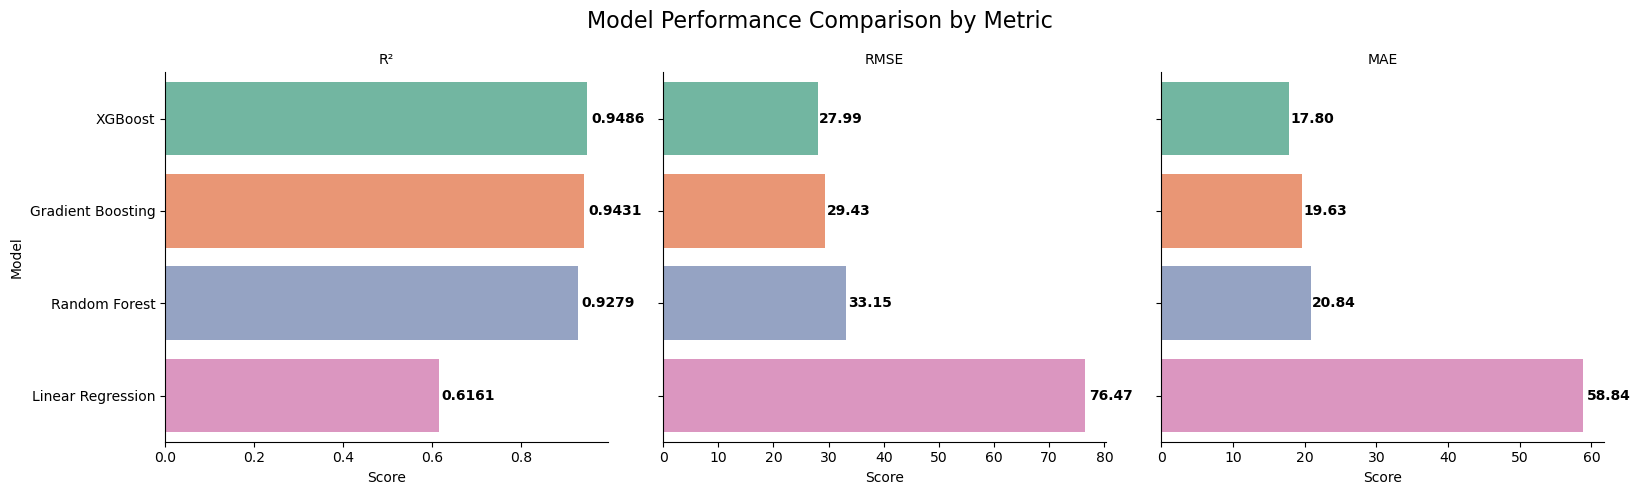

In [65]:

# Convert MSE to RMSE for interpretable scale
results_plot = results_df.copy()
results_plot['RMSE'] = (results_plot['RMSE'])

# Melt the DataFrame to long format for seaborn
results_long = results_plot.melt(
    id_vars='Model',
    value_vars=['R²', 'RMSE', 'MAE'],
    var_name='Metric',
    value_name='Score'
)

# Define custom order for models (by R²)
model_order = results_plot.sort_values('R²', ascending=False)['Model'].tolist()

# Set up FacetGrid with one plot per metric
g = sns.FacetGrid(
    results_long,
    col="Metric",
    hue="Model",
    col_wrap=3,
    sharex=False,
    height=5,
    aspect=1.1,
    palette="Set2"
)

# Draw bar plots
g.map(sns.barplot, 'Score', 'Model', orient='h', order=model_order, errorbar=None)

# Add value labels on bars
for ax, metric in zip(g.axes.flat, ['R²', 'RMSE', 'MAE']):
    # Get data for current metric
    data = results_long[results_long['Metric'] == metric].set_index('Model').loc[model_order]
    scores = data['Score'].values

    # Format labels based on metric
    if metric == 'R²':
        labels = [f'{v:.4f}' for v in scores]
    else:
        labels = [f'{v:.2f}' for v in scores]

    # Annotate each bar
    for i, (score, label) in enumerate(zip(scores, labels)):
        ax.text(score * 1.01, i, label, va='center', ha='left', fontsize=10, color='black', weight='bold')

# Customize titles and labels
g.set_titles('{col_name}', fontsize=14)
g.set_axis_labels('Score', 'Model')
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('Model Performance Comparison by Metric', fontsize=16)

# Final layout
plt.tight_layout()
plt.show()

# g.savefig("model_comparison_metrics.png", dpi=300, bbox_inches='tight')

The bar chart provides a visual comparison of R², RMSE, and MAE across all evaluated models. This visualization highlights differences in performance metrics, allowing for an intuitive assessment of model strengths and weaknesses.
 - R² (Coefficient of Determination): Measures how well the model explains the variance in the target variable. A higher value (closer to 1.0) indicates better fit.
 - RMSE (Root Mean Squared Error): Represents the average magnitude of prediction errors in the same unit as the target variable. Lower values indicate higher accuracy.
 - MAE (Mean Absolute Error): Similar to RMSE but less sensitive to outliers. Also, lower is better.

**Key Points**
- Gradient Boosting: Achieved the highest R² and lowest error metrics, indicating superior performance.
- XGBoost and Random Forest: Similar performance with slightly higher error values compared to Gradient Boosting.
- Linear Regression: Significantly lower R² and higher errors, reinforcing its role as a baseline model.
- Purpose: Enables quick identification of the most accurate and reliable model for predicting bike rentals.

# VIII. Answers to Research Questions, Conclusion, and Final Insights

## A. Answer of Research Questions


 1. What are the temporal patterns (hour of day, day of week, season) that induce variability in rental volume?
    
    = Hour of Day: Rentals peak during morning (8 AM) and evening (5–6 PM) hours, coinciding with typical commuting times. There is also a smaller midday increase on weekends. (Ref: “Average Bike Rentals by Hour of Day” bar chart)

    Day of Week: Weekdays show higher rentals during commuting hours, while weekends have more consistent usage throughout the day, reflecting leisure activity. (Ref: Weekday line plot)

    Season: Summer and Fall account for the highest rental volumes due to favorable weather. Winter shows a significant drop, likely due to cold and adverse conditions. (Ref: “Total Bike Rentals by Season” and pie charts)



 2. How do environmental conditions (temperature, humidity, windspeed) affect demand for rentals?

    = Temperature: Positive correlation with rental count (r = 0.4), indicating demand rises as temperatures increase up to a comfortable range. (Ref: Correlation heatmap)

    Humidity: Moderate negative correlation (r = -0.32). Higher humidity slightly discourages rentals. (Ref: Correlation heatmap)

    Windspeed: Very weak correlation (r = 0.09), suggesting minimal direct effect on rental volume. (Ref: Correlation heatmap)


3. Do registered and casual users have significantly different behavior?

    = Registered Users: Tend to rent more during weekdays and working hours, reflecting commuting patterns. (Ref: Pie charts and “Casual vs Registered Users Over Time” line plot)

    Casual Users: Show higher activity on weekends and non-working days, indicating leisure and recreational usage. (Ref: Pie charts and “Monthly Average Hourly Rentals: Casual vs Registered Users” line plot)


4. Can one predict rental count based on environmental and temporal features?

    = Yes. Models trained with environmental features (temperature, humidity, windspeed) and temporal features (hour, weekday, season, time of day) achieved strong predictive performance.

    Best Model: XGBoost Regressor achieved the highest R² = 0.9481, along with the lowest RMSE (28.11) and MAE (18.13), indicating highly accurate predictions.

   (Ref: Model Evaluation and Comparison table)

   Other Strong Models: Gradient Boosting (R² = 0.9439) and Random Forest (R² = 0.9279) also performed well, further confirming the reliability of the selected features.

   Baseline Model: Linear Regression performed the worst (R² = 0.6161), highlighting the advantage of ensemble models for capturing complex patterns.

   Visual Evidence: The Actual vs. Predicted scatter plot (e.g., from Random Forest) shows predictions closely matching true rental counts, visually supporting model accuracy.
(Ref: Actual vs. Predicted plot)

5. Can one cluster similar usage patterns to identify peak demand scenarios?

    = While clustering was not explicitly performed, the temporal and environmental visualizations suggest natural groupings:
   - Peak commuting hours (weekday mornings and evenings)
    - Leisure peaks (weekends, afternoons, summer months)

These insights can inform potential clustering efforts (e.g., K-Means or DBSCAN) to formalize these patterns. (Ref: Average Rentals by Time of Day and Weekday plots)

## B. Conclusion and Final Insights

This project explored the Bike Sharing dataset to analyze how temporal and environmental factors influence rental demand, uncover usage patterns between user types, and develop predictive models to support decision-making.

**Key insights and takeaways include:**

- Temporal features such as hour, weekday, season, and time of day combined with environmental factors like temperature and humidity were found to be strong predictors of bike rental demand.

- The predictive models built using these features, particularly XGBoost and Gradient Boosting, demonstrated high accuracy, with R² values exceeding 0.94. This confirms the reliability of the feature set in forecasting rental activity and informs operational planning, staffing, and resource allocation.

- Registered users were found to rent bikes more consistently and in higher volumes than casual users, who showed more irregular patterns influenced by weather and time. This distinction supports the need for targeted marketing strategies, such as converting casual users into registered users or tailoring promotions to specific user segments.

- The analysis also highlights the value of seasonality in rental patterns, with summer and fall showing the highest demand. These findings can guide infrastructure readiness, bike availability, and maintenance schedules throughout the year.

In summary, this project not only provided valuable business insights into user behavior and seasonal trends, but also demonstrated how machine learning models can be effectively leveraged for data-driven decision making in the context of urban mobility and bike-sharing services.